# Final Experiment Analysis
Analysis of deletion ratio, TVD, marginal error, and runtime across all datasets and algorithms.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load aggregated data
df = pd.read_csv('../experiment_results_summary.csv')

# Map new flattened column names to expected shorter names
rename_map = {
    'meta_repairer_params_use_marginals': 'use_marginals',
    'meta_repairer_params_alpha': 'alpha',
    'meta_obtainer_params_k': 'k',
    'meta_obtainer_params_selection_budget': 'sel_budget',
    'meta_obtainer_params_generation_budget': 'gen_budget',
    'meta_synthesizer_params_seed': 'seed',
    'meta_synthesizer_params_size': 'iters'
}
df = df.rename(columns=rename_map)

# Clean up names
df['repairer'] = df['repairer'].str.replace('Repairer', '').str.replace('VC', '-VC')
df.loc[df['use_marginals'] == True, 'repairer'] = df['repairer'] + ' (Marginals)'
df['engine'] = df['engine'].fillna('CoNoise')

# Data Validation: Show distribution of results by date
df['date'] = pd.to_datetime(df['timestamp']).dt.date
print("### Data Validation: Results by Date")
print(df.groupby('date').size())

print("\n### Results by Experiment Name")
print(df.groupby('experiment_name').size())

# Map columns to metrics
metric_map = {
    'deletion_ratio_ratio': 'Deletion Ratio',
    'tvd_2way_repaired_avg': 'Total Variation Distance (TVD)',
    'marginals_error_repaired_avg': 'Marginal Error',
    'runtime_repairing': 'Repair Runtime (seconds)',
    'loss_function_synthetic_marginal_component': 'Synthetic Marginals Distance',
    'tvd_2way_synthetic_avg': 'TVD to Synthetic Data',
    'loss_function_repaired_total': 'Total Loss Function Value',
    'loss_function_repaired_marginal_component': 'Marginals Loss Function Component',
    'loss_function_repaired_size_component': 'Size Loss Function Component',
    'ml_accuracy_repaired_logistic_regression': 'ML Accuracy Repaired Logistic Regression',
    'ml_accuracy_repaired_random_forest': 'ML Accuracy Repaired Random Forest',
    'ml_accuracy_repaired_mlp': 'ML Accuracy Repaired MLP'
}

def analyze_dataset(dataset_name):
    ds_df = df[df['dataset'] == dataset_name].copy()
    if ds_df.empty:
        print(f"No data found for dataset: {dataset_name}")
        return
    
    print(f"\n# Analysis for Dataset: {dataset_name.upper()}")
    
    for col, title in metric_map.items():
        # Pivot for table
        pivot = ds_df.groupby(['repairer', 'engine'])[col].mean().unstack()
        print(f"\n### {title}")
        display(pivot)
        
        # Visualization: Enhanced Heatmap
        plt.figure(figsize=(10, 7))
        sns.set_theme(style="white")
        
        # Create heatmap with better aesthetics
        sns.heatmap(
            pivot, 
            annot=True, 
            fmt=".4f", 
            cmap="RdYlGn_r", 
            linewidths=.5, 
            cbar_kws={'label': title}
        )
        
        plt.title(f"{title}\n{dataset_name.upper()} Dataset", fontsize=14, pad=20)
        plt.xlabel("Generation Engine", fontsize=12)
        plt.ylabel("Repair Algorithm", fontsize=12)
        plt.tight_layout()
        plt.show()
        sns.set_theme(style="whitegrid")


### Data Validation: Results by Date
date
2026-05-08    246
dtype: int64

### Results by Experiment Name
experiment_name
may_2026_batch       174
weighted_fix_test     36
weighted_fix_v2       36
dtype: int64


In [65]:
df.columns 

Index(['dataset', 'experiment_name', 'experiment_id', 'timestamp',
       'meta_loader', 'meta_synthesizer', 'meta_obtainer', 'meta_repairer',
       'meta_synthesizer_params_model_path', 'iters', 'seed', 'sel_budget',
       'gen_budget', 'k', 'meta_obtainer_params_seed', 'alpha',
       'use_marginals', 'repairer', 'synthesizer', 'engine', 'runtime_loading',
       'runtime_synthesizing', 'runtime_marginals_obtaining',
       'runtime_repairing', 'deletion_ratio_before', 'deletion_ratio_after',
       'deletion_ratio_ratio', 'marginals_error_synthetic_avg',
       'marginals_error_repaired_avg', 'tvd_2way_synthetic_avg',
       'tvd_2way_repaired_avg', 'ml_accuracy_synthetic_logistic_regression',
       'ml_accuracy_synthetic_random_forest', 'ml_accuracy_synthetic_mlp',
       'ml_accuracy_repaired_logistic_regression',
       'ml_accuracy_repaired_random_forest', 'ml_accuracy_repaired_mlp',
       'violations_private', 'violations_synthetic', 'violations_repaired',
       'loss_func

## Dataset: ADULT


# Analysis for Dataset: ADULT

### Deletion Ratio


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.086667,0.034667,0.996000
ILP,0.044667,0.017667,0.963000
ILP (Marginals),0.044667,0.017667,1.000000
Vanilla-VC,0.044667,0.017667,0.970333
Weighted-VC,0.044667,0.017667,0.970333
Weighted-VC_fixed,0.044667,0.017667,0.970333
Weighted-VC_v2,0.044667,0.017667,0.970333


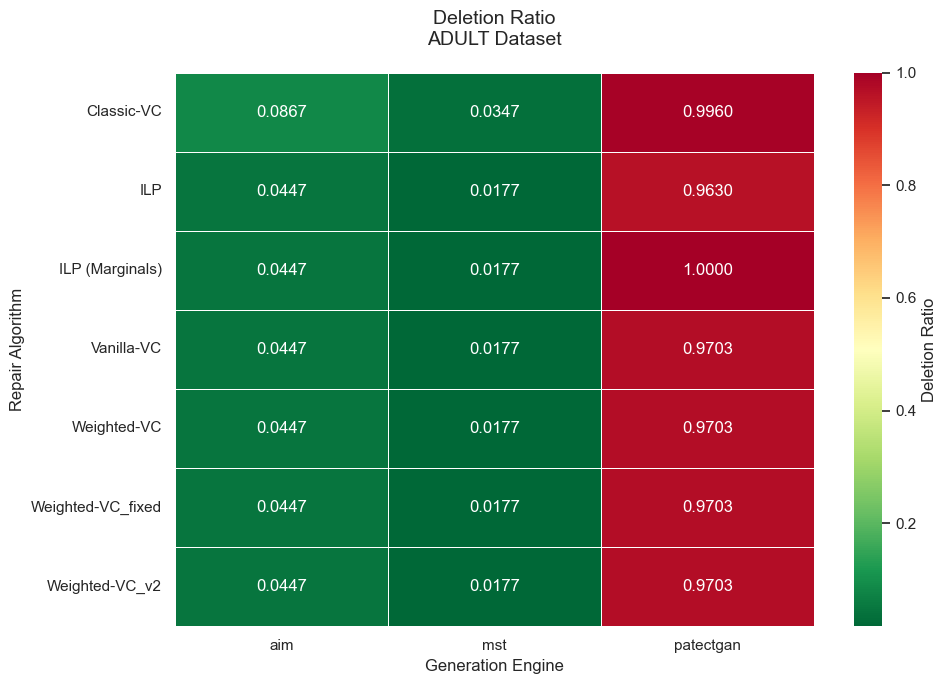


### Total Variation Distance (TVD)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.078516,0.080825,0.953992
ILP,0.074836,0.079926,0.849738
ILP (Marginals),0.074836,0.079926,0.500000
Vanilla-VC,0.074836,0.079926,0.859662
Weighted-VC,0.074836,0.079926,0.849207
Weighted-VC_fixed,0.074836,0.079926,0.849207
Weighted-VC_v2,0.074836,0.079926,0.856285


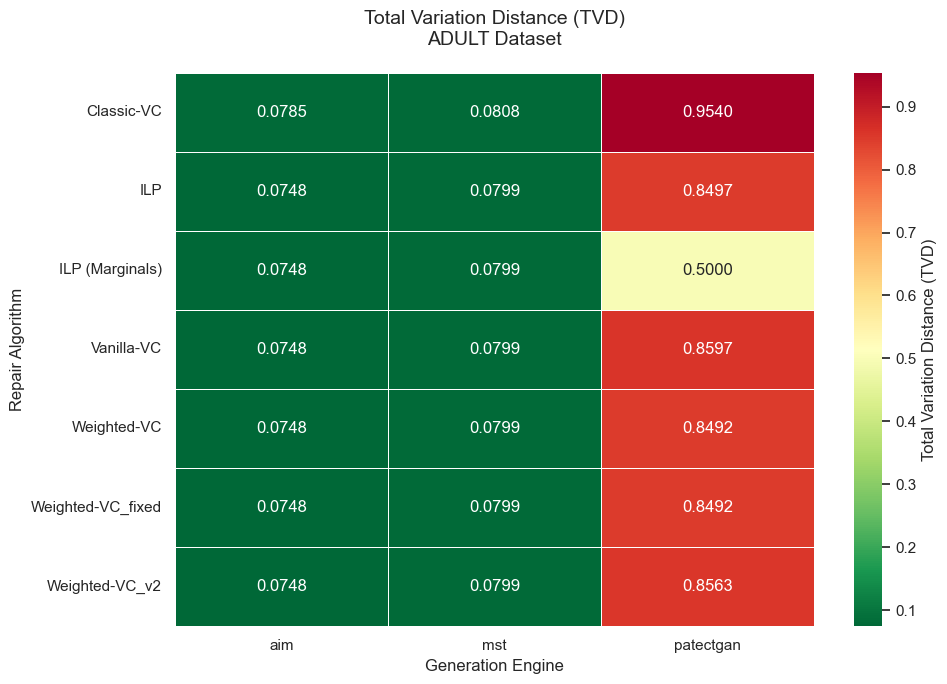


### Marginal Error


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.225215,0.454692,6.489477e+06
ILP,0.228215,0.449754,4.696603e+06
ILP (Marginals),0.228215,0.449754,6.834695e+06
Vanilla-VC,0.228215,0.449754,5.159624e+06
Weighted-VC,0.228215,0.449754,4.172707e+06
Weighted-VC_fixed,0.228215,0.449754,4.172707e+06
Weighted-VC_v2,0.228215,0.449754,4.954286e+06


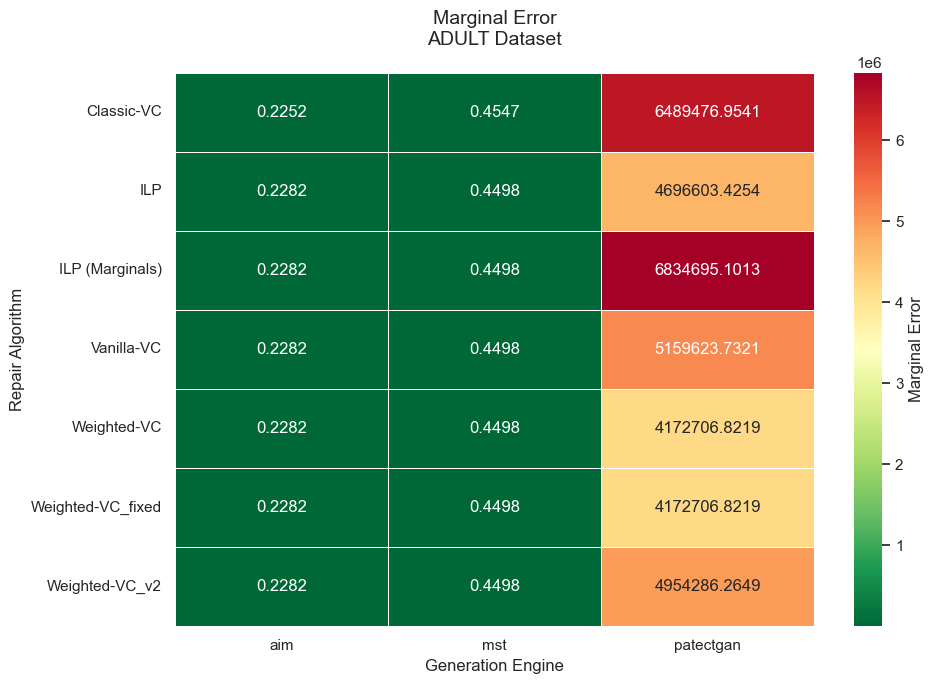


### Repair Runtime (seconds)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.253896,0.161909,7.066086
ILP,1.006285,0.835659,6309.224757
ILP (Marginals),34.420776,13.745097,4103.492475
Vanilla-VC,0.239942,0.185049,6.885392
Weighted-VC,0.294367,0.229146,7.608902
Weighted-VC_fixed,0.309981,0.166265,8.112272
Weighted-VC_v2,0.323194,0.188488,8.010337


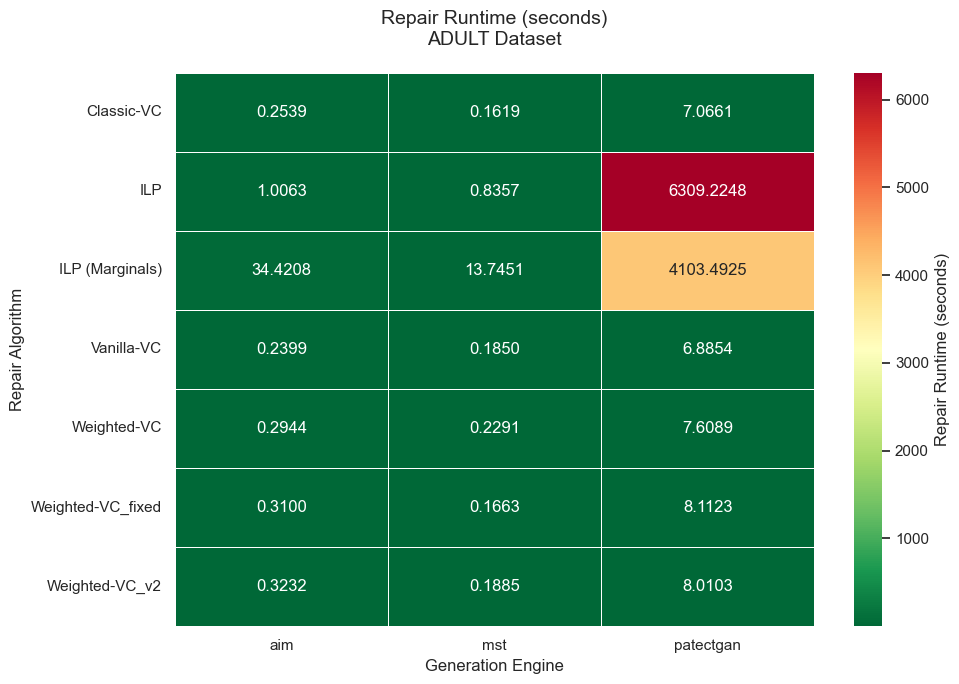


### Synthetic Marginals Distance


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.01352,0.026911,0.660586
ILP,0.01352,0.026911,0.660586
ILP (Marginals),0.01352,0.026911,0.660586
Vanilla-VC,0.01352,0.026911,0.660586
Weighted-VC,0.01352,0.026911,0.660586
Weighted-VC_fixed,0.01352,0.026911,0.660586
Weighted-VC_v2,0.01352,0.026911,0.660586


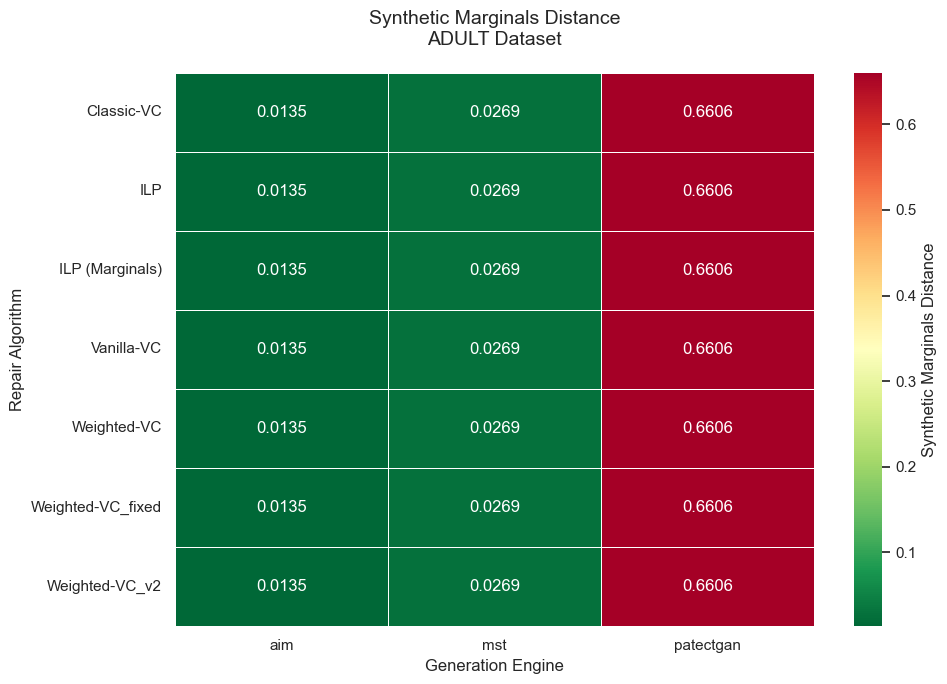


### TVD to Synthetic Data


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.071791,0.078828,0.73684
ILP,0.071791,0.078828,0.73684
ILP (Marginals),0.071791,0.078828,0.73684
Vanilla-VC,0.071791,0.078828,0.73684
Weighted-VC,0.071791,0.078828,0.73684
Weighted-VC_fixed,0.071791,0.078828,0.73684
Weighted-VC_v2,0.071791,0.078828,0.73684


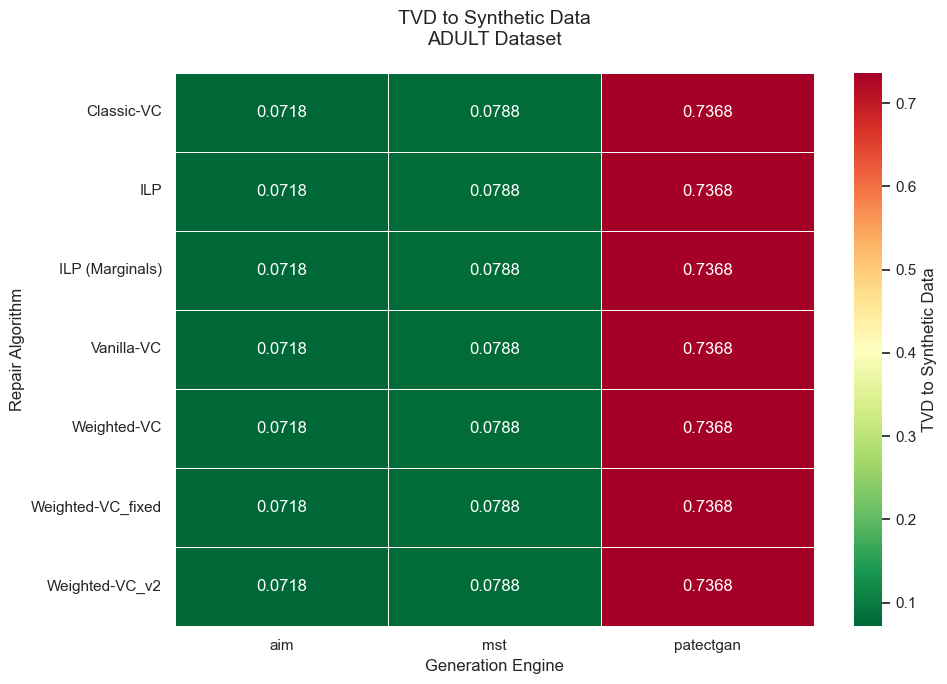


### Total Loss Function Value


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.049134,0.030706,0.829318
ILP,0.028505,0.022171,0.813308
ILP (Marginals),0.028505,0.022171,0.841735
Vanilla-VC,0.028505,0.022171,0.817393
Weighted-VC,0.028505,0.022171,0.811240
Weighted-VC_fixed,0.028505,0.022171,0.811240
Weighted-VC_v2,0.028505,0.022171,0.817083


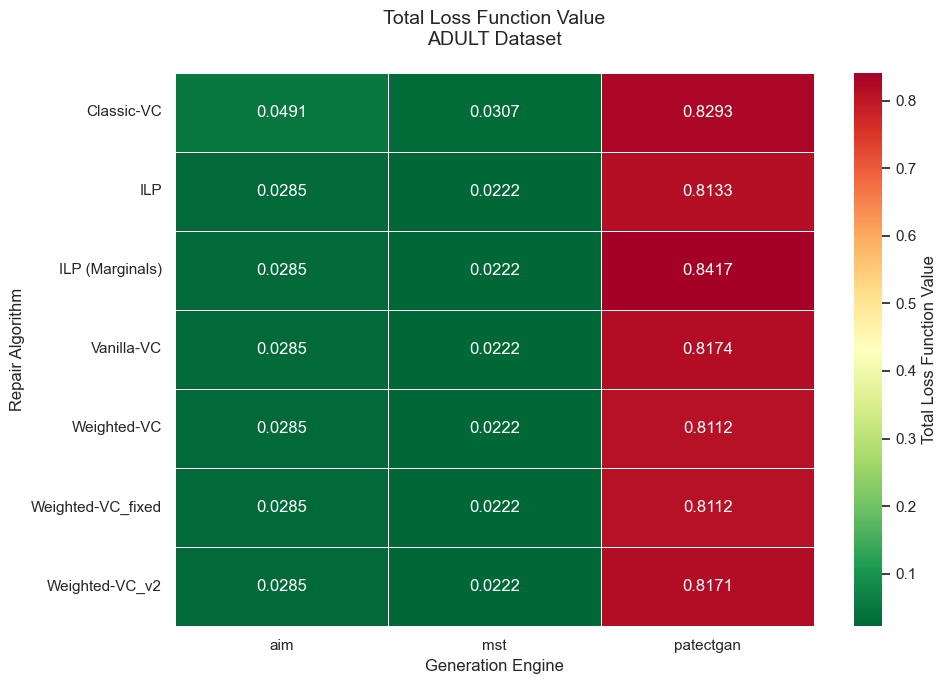


### Marginals Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.011602,0.026746,0.662636
ILP,0.012343,0.026675,0.663615
ILP (Marginals),0.012343,0.026675,0.683470
Vanilla-VC,0.012343,0.026675,0.664453
Weighted-VC,0.012343,0.026675,0.652147
Weighted-VC_fixed,0.012343,0.026675,0.652147
Weighted-VC_v2,0.012343,0.026675,0.663833


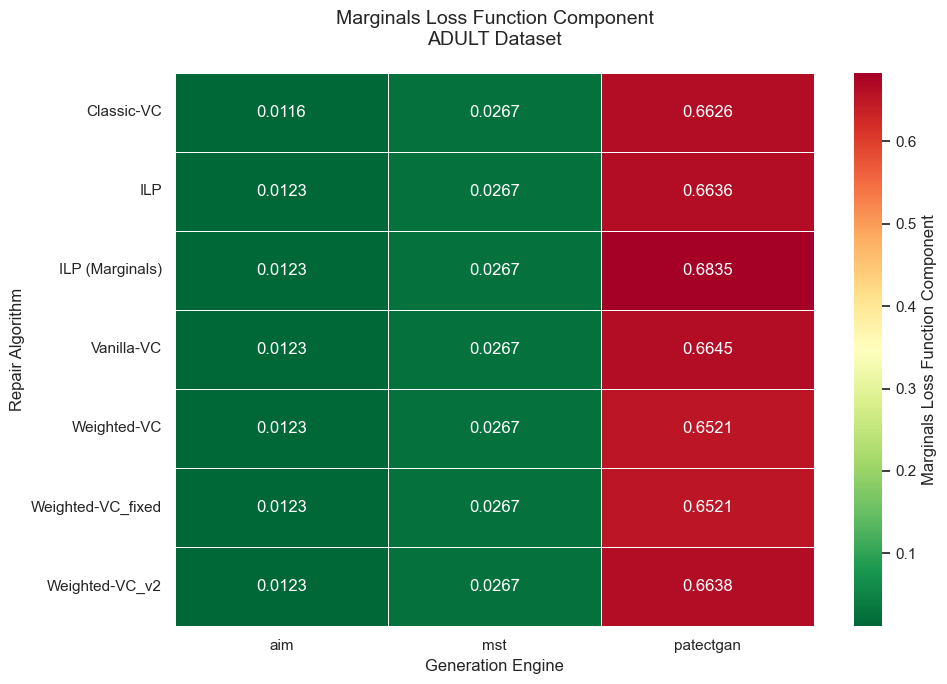


### Size Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.086667,0.034667,0.996000
ILP,0.044667,0.017667,0.963000
ILP (Marginals),0.044667,0.017667,1.000000
Vanilla-VC,0.044667,0.017667,0.970333
Weighted-VC,0.044667,0.017667,0.970333
Weighted-VC_fixed,0.044667,0.017667,0.970333
Weighted-VC_v2,0.044667,0.017667,0.970333


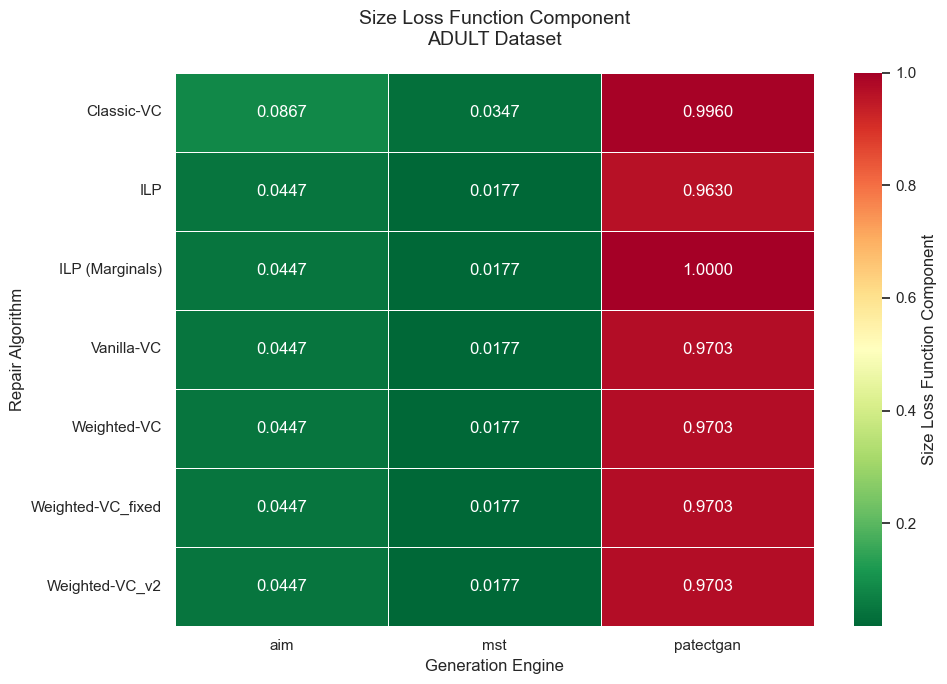


### ML Accuracy Repaired Logistic Regression


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.818380,0.803537,0.620777
ILP,0.819534,0.803905,0.415988
ILP (Marginals),0.819534,0.803905,0.000000
Vanilla-VC,0.819534,0.803905,0.350627
Weighted-VC,0.819534,0.803905,0.367164
Weighted-VC_fixed,0.819534,0.803905,0.367164
Weighted-VC_v2,0.819534,0.803905,0.598037


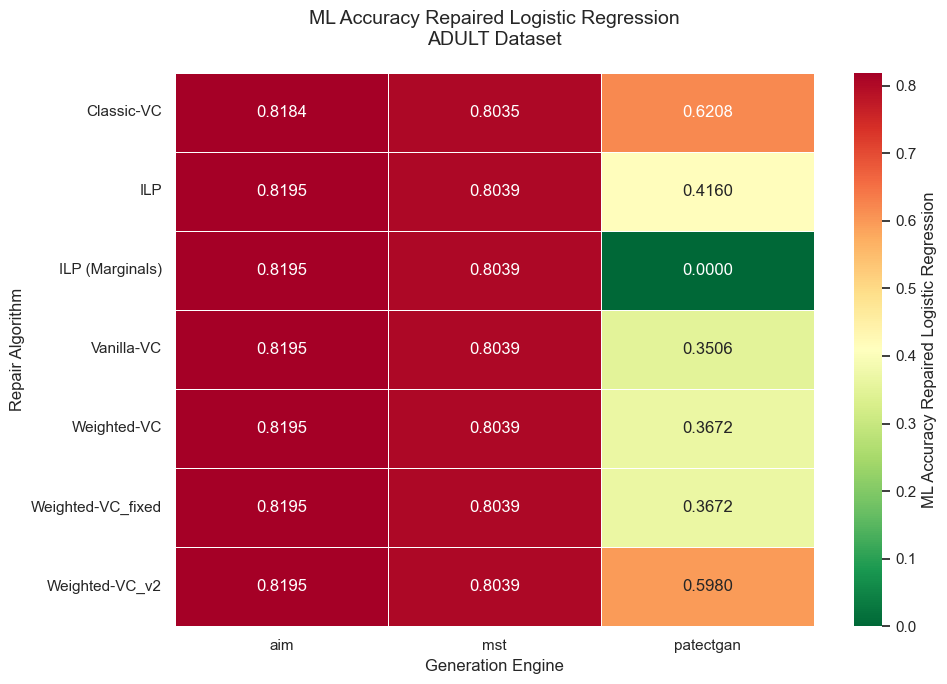


### ML Accuracy Repaired Random Forest


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.842779,0.791006,0.722950
ILP,0.841830,0.791627,0.516939
ILP (Marginals),0.841830,0.791627,0.000000
Vanilla-VC,0.841830,0.791627,0.391111
Weighted-VC,0.841830,0.791627,0.487920
Weighted-VC_fixed,0.841830,0.791627,0.487920
Weighted-VC_v2,0.841830,0.791627,0.570984


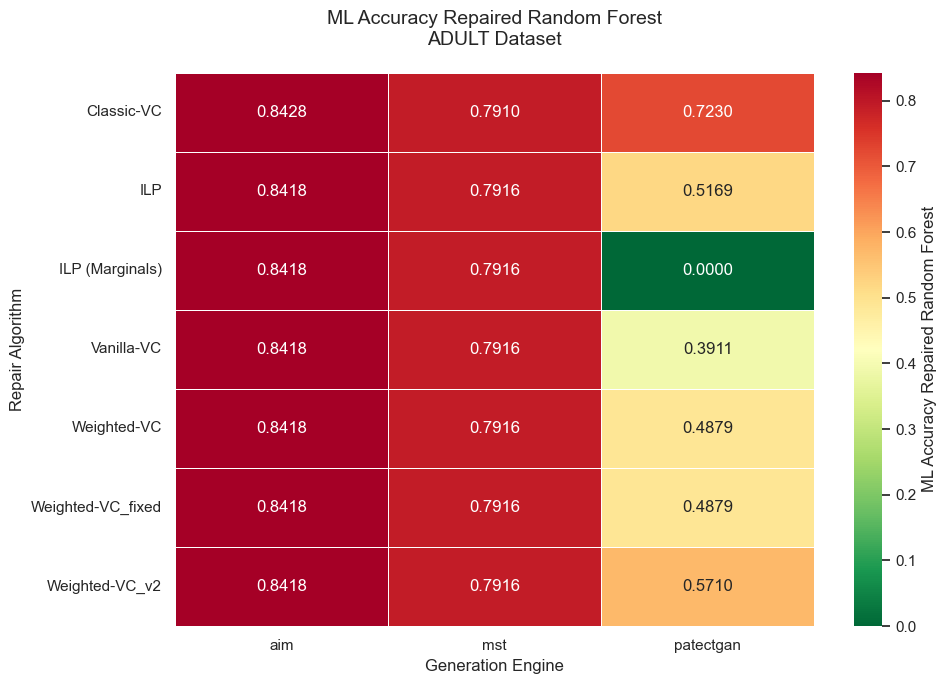


### ML Accuracy Repaired MLP


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.806792,0.760275,0.549302
ILP,0.807140,0.758807,0.407614
ILP (Marginals),0.807140,0.758807,0.000000
Vanilla-VC,0.807140,0.758807,0.347181
Weighted-VC,0.807140,0.758807,0.329027
Weighted-VC_fixed,0.807140,0.758807,0.329027
Weighted-VC_v2,0.807140,0.758807,0.586012


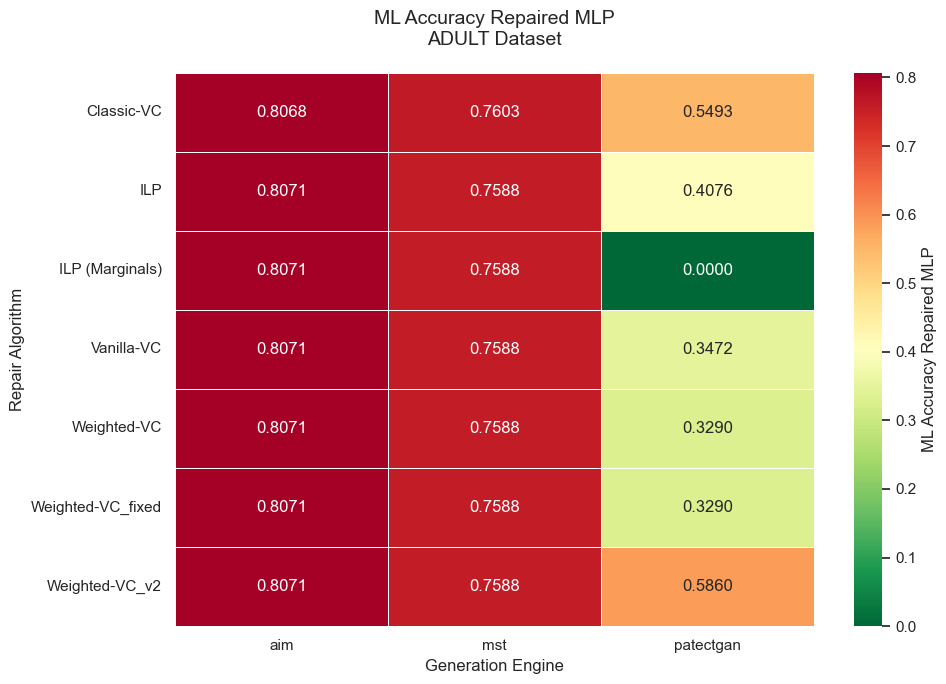

In [66]:
analyze_dataset('adult')

## Dataset: CENSUS


# Analysis for Dataset: CENSUS

### Deletion Ratio


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.001333,0.004,0.972000
ILP,0.000667,0.002,0.846333
ILP (Marginals),0.000667,0.002,NaN
Vanilla-VC,0.000667,0.002,0.847333
Weighted-VC,0.000667,0.002,0.848000
Weighted-VC_fixed,0.000667,0.002,0.848000
Weighted-VC_v2,0.000667,0.002,0.847333


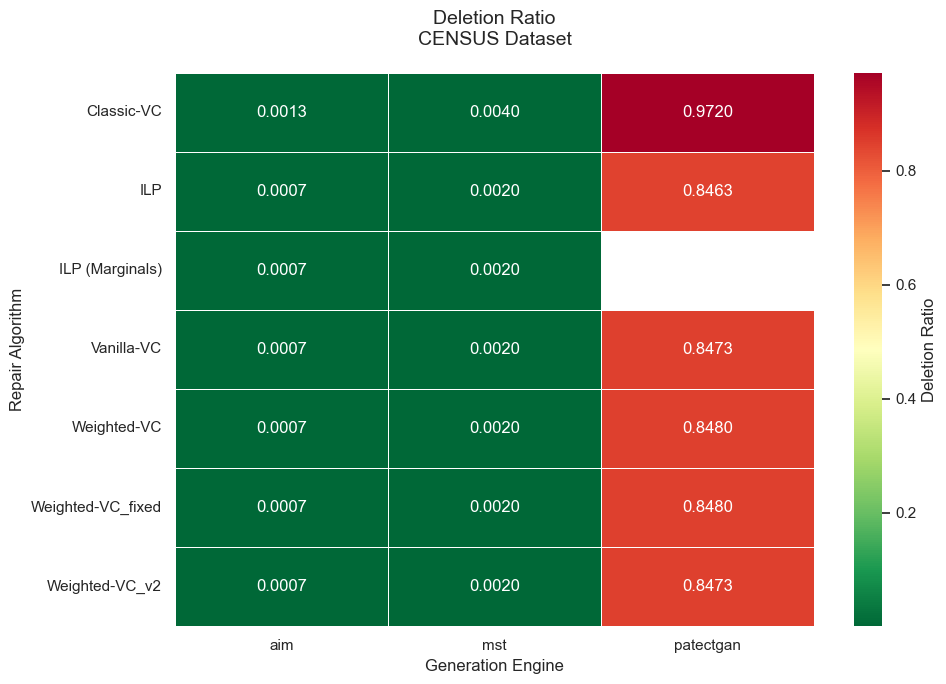


### Total Variation Distance (TVD)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.103913,0.101059,0.803741
ILP,0.103839,0.100878,0.721339
ILP (Marginals),0.103839,0.100878,NaN
Vanilla-VC,0.103839,0.100878,0.714762
Weighted-VC,0.103839,0.100878,0.706403
Weighted-VC_fixed,0.103839,0.100878,0.706403
Weighted-VC_v2,0.103839,0.100878,0.706524


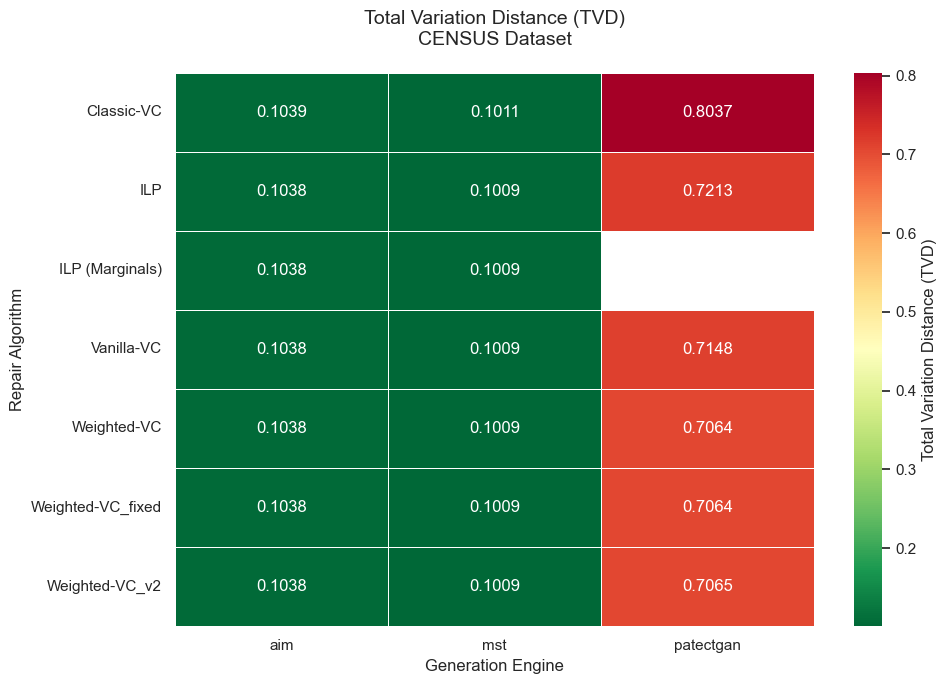


### Marginal Error


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.255847,0.230239,1.056046e+06
ILP,0.256456,0.230450,5.435585e+05
ILP (Marginals),0.256456,0.230450,NaN
Vanilla-VC,0.256456,0.230450,3.216764e+05
Weighted-VC,0.256456,0.230450,3.809376e+05
Weighted-VC_fixed,0.256456,0.230450,3.809376e+05
Weighted-VC_v2,0.256456,0.230450,4.083630e+05


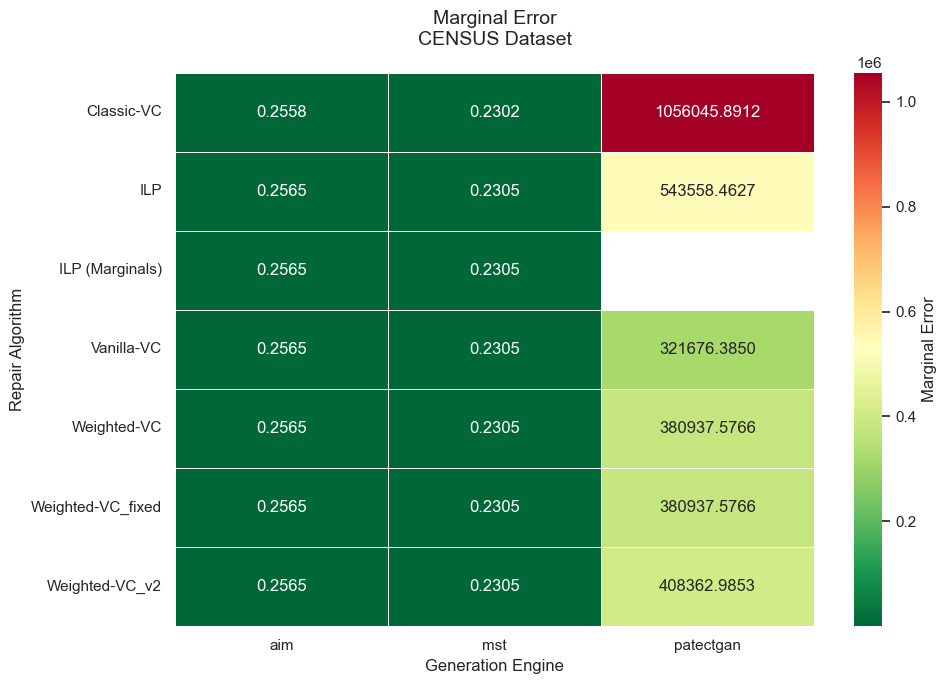


### Repair Runtime (seconds)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.019114,0.022233,2.223365
ILP,0.045601,0.417044,87.049641
ILP (Marginals),6.932322,8.347577,NaN
Vanilla-VC,0.018637,0.020680,2.078321
Weighted-VC,0.025863,0.025805,3.336294
Weighted-VC_fixed,0.020766,0.026967,3.192200
Weighted-VC_v2,0.020544,0.025276,3.251082


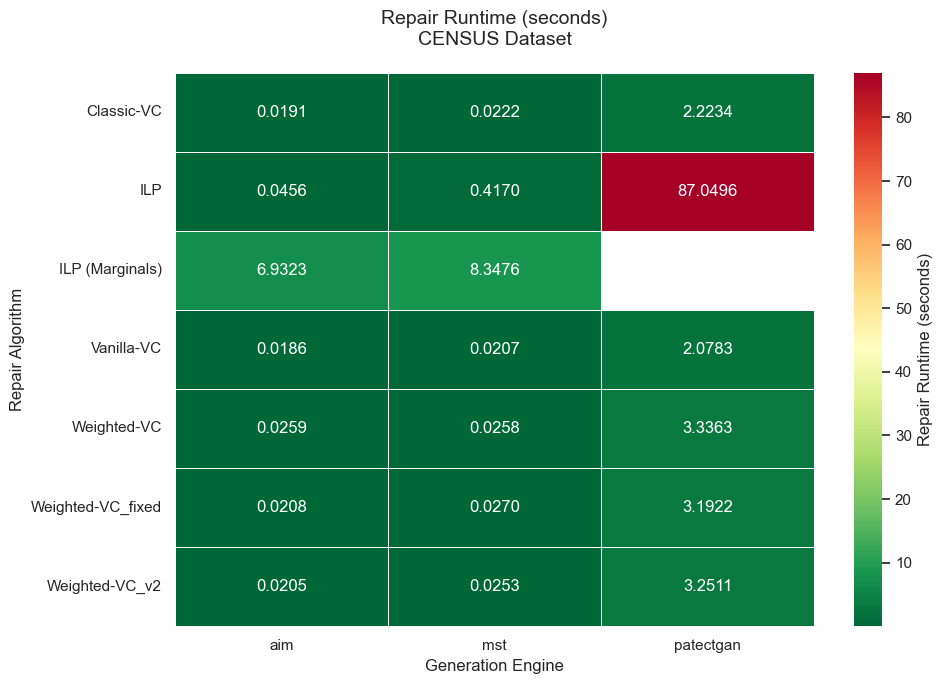


### Synthetic Marginals Distance


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.008993,0.014472,0.240626
ILP,0.008993,0.014472,0.240626
ILP (Marginals),0.008993,0.014472,NaN
Vanilla-VC,0.008993,0.014472,0.240626
Weighted-VC,0.008993,0.014472,0.240626
Weighted-VC_fixed,0.008993,0.014472,0.240626
Weighted-VC_v2,0.008993,0.014472,0.240626


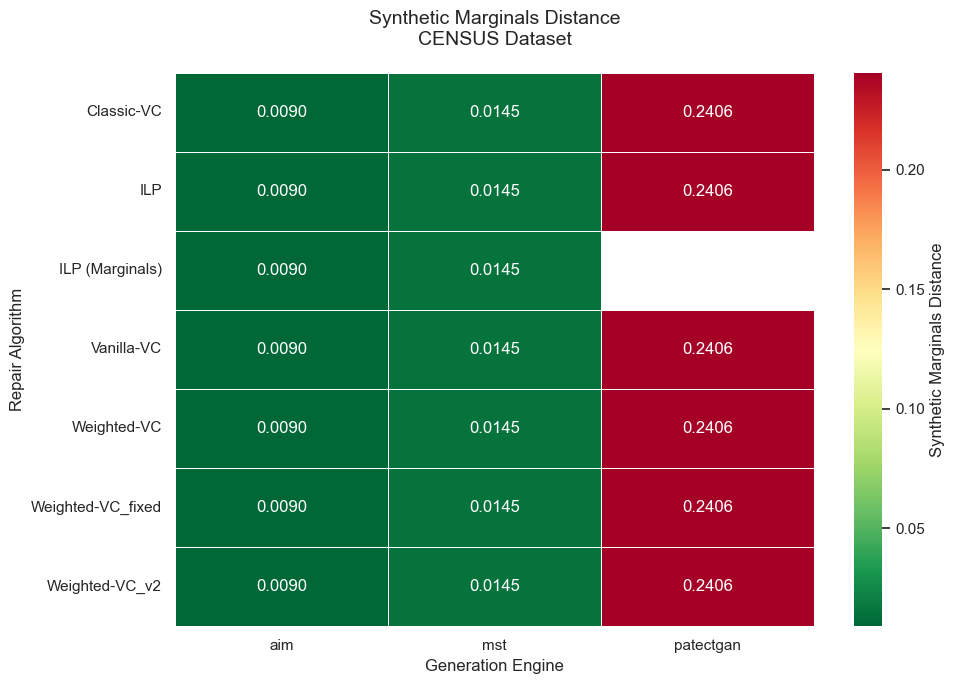


### TVD to Synthetic Data


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.103828,0.100787,0.642248
ILP,0.103828,0.100787,0.642248
ILP (Marginals),0.103828,0.100787,NaN
Vanilla-VC,0.103828,0.100787,0.642248
Weighted-VC,0.103828,0.100787,0.642248
Weighted-VC_fixed,0.103828,0.100787,0.642248
Weighted-VC_v2,0.103828,0.100787,0.642248


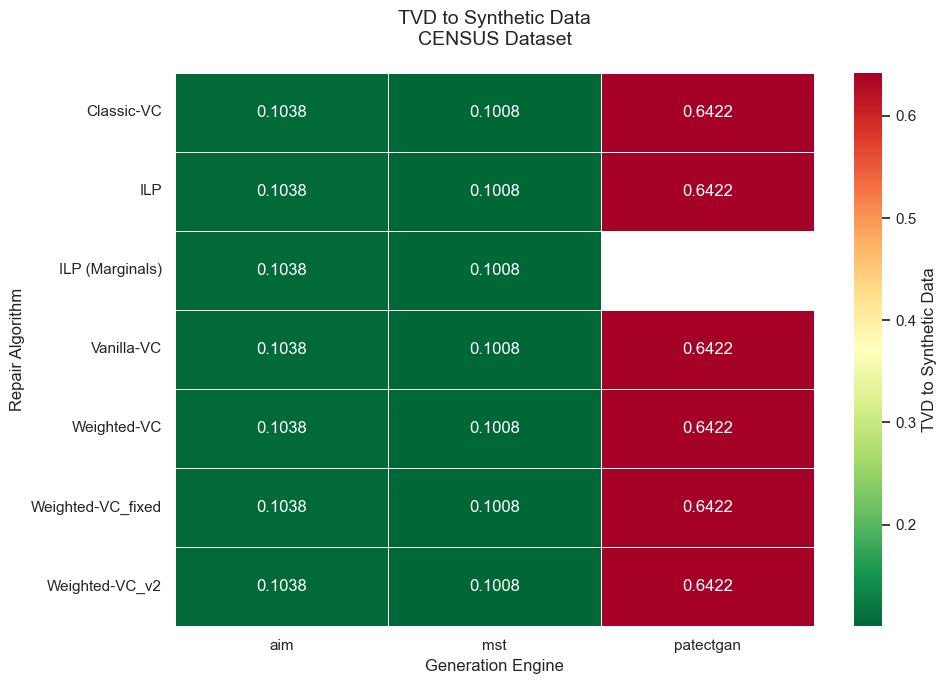


### Total Loss Function Value


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.005158,0.009372,0.598643
ILP,0.004832,0.008333,0.538862
ILP (Marginals),0.004832,0.008333,NaN
Vanilla-VC,0.004832,0.008333,0.539958
Weighted-VC,0.004832,0.008333,0.535480
Weighted-VC_fixed,0.004832,0.008333,0.535480
Weighted-VC_v2,0.004832,0.008333,0.536654


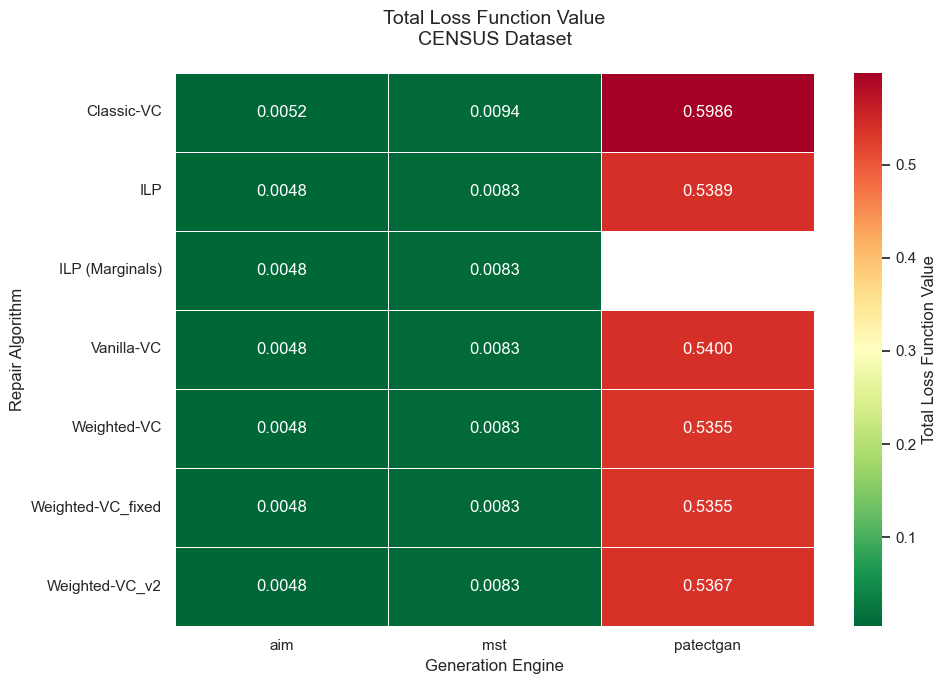


### Marginals Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.008983,0.014744,0.225287
ILP,0.008996,0.014666,0.231391
ILP (Marginals),0.008996,0.014666,NaN
Vanilla-VC,0.008996,0.014666,0.232582
Weighted-VC,0.008996,0.014666,0.222961
Weighted-VC_fixed,0.008996,0.014666,0.222961
Weighted-VC_v2,0.008996,0.014666,0.225975


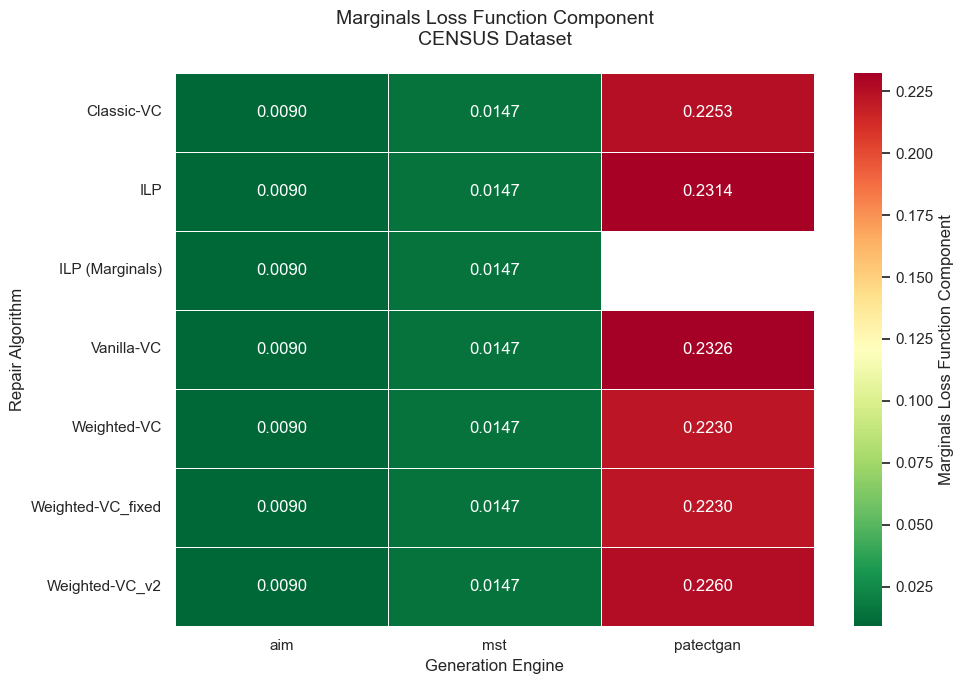


### Size Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.001333,0.004,0.972000
ILP,0.000667,0.002,0.846333
ILP (Marginals),0.000667,0.002,NaN
Vanilla-VC,0.000667,0.002,0.847333
Weighted-VC,0.000667,0.002,0.848000
Weighted-VC_fixed,0.000667,0.002,0.848000
Weighted-VC_v2,0.000667,0.002,0.847333


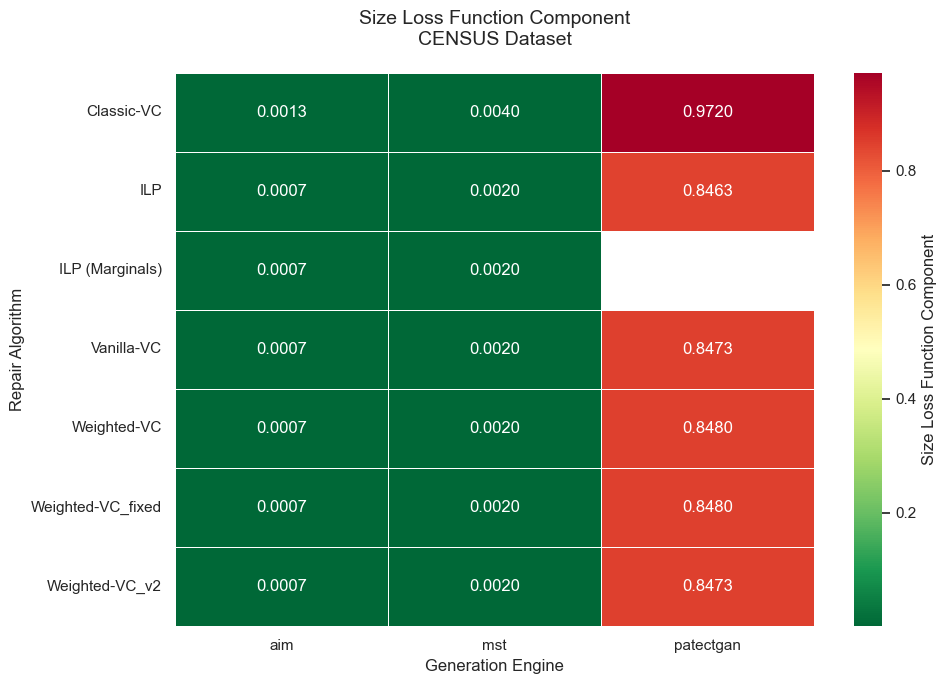


### ML Accuracy Repaired Logistic Regression


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.618392,0.619707,0.012935
ILP,0.618378,0.619702,0.014394
ILP (Marginals),0.618378,0.619702,NaN
Vanilla-VC,0.618378,0.619702,0.043461
Weighted-VC,0.618378,0.619702,0.031974
Weighted-VC_fixed,0.618378,0.619702,0.031974
Weighted-VC_v2,0.618378,0.619702,0.030120


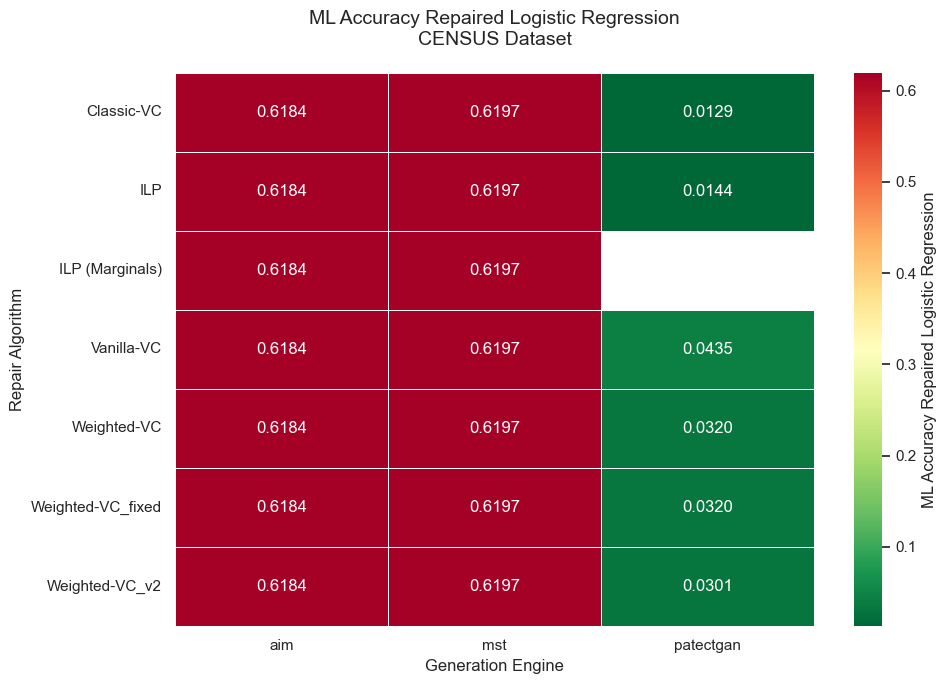


### ML Accuracy Repaired Random Forest


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.578710,0.572656,0.015002
ILP,0.579015,0.573613,0.023441
ILP (Marginals),0.579015,0.573613,NaN
Vanilla-VC,0.579015,0.573613,0.031011
Weighted-VC,0.579015,0.573613,0.045038
Weighted-VC_fixed,0.579015,0.573613,0.045038
Weighted-VC_v2,0.579015,0.573613,0.043216


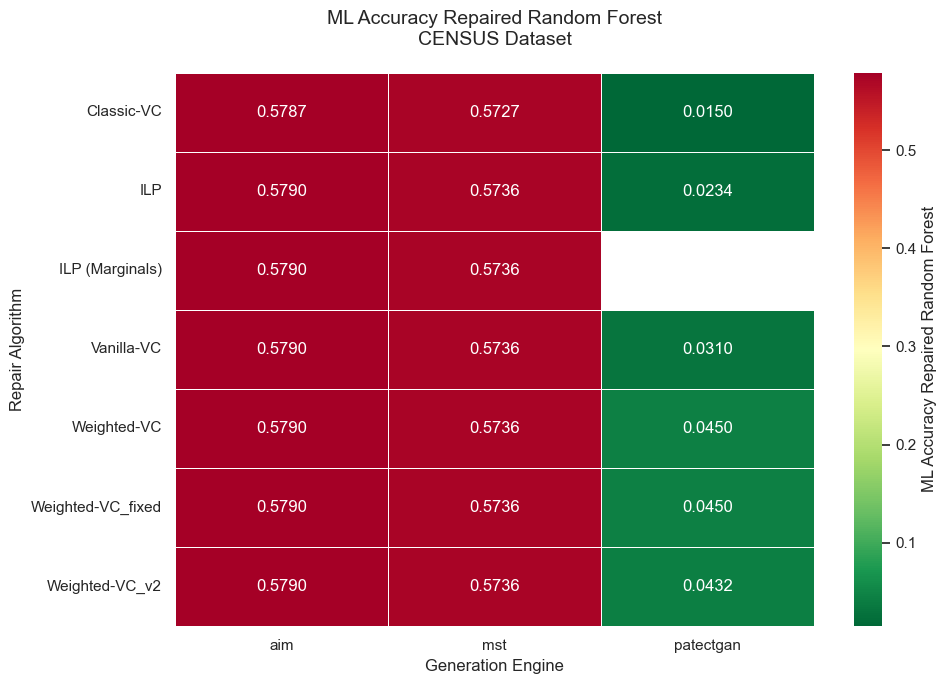


### ML Accuracy Repaired MLP


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.573069,0.563147,0.015046
ILP,0.574164,0.562744,0.019456
ILP (Marginals),0.574164,0.562744,NaN
Vanilla-VC,0.574164,0.562744,0.038271
Weighted-VC,0.574164,0.562744,0.037201
Weighted-VC_fixed,0.574164,0.562744,0.037201
Weighted-VC_v2,0.574164,0.562744,0.043184


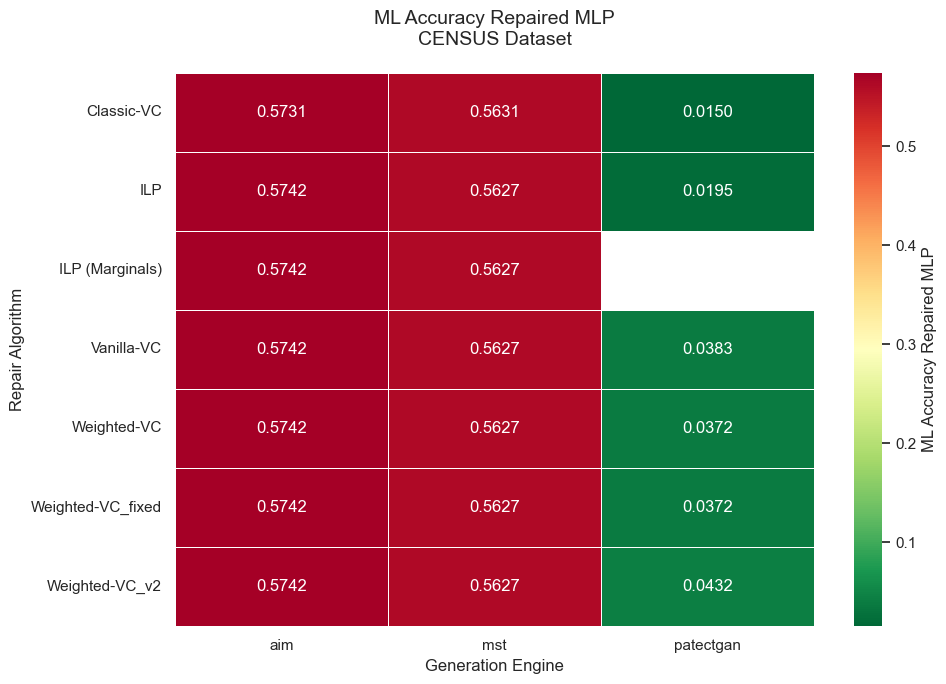

In [67]:
analyze_dataset('census')

## Dataset: COMPAS


# Analysis for Dataset: COMPAS

### Deletion Ratio


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.018667,0.013333,0.998000
ILP,0.009333,0.006667,0.909333
ILP (Marginals),0.009333,0.006667,NaN
Vanilla-VC,0.009333,0.006667,0.925667
Weighted-VC,0.009333,0.006667,0.922000
Weighted-VC_fixed,0.009333,0.006667,0.922000
Weighted-VC_v2,0.009333,0.006667,0.922667


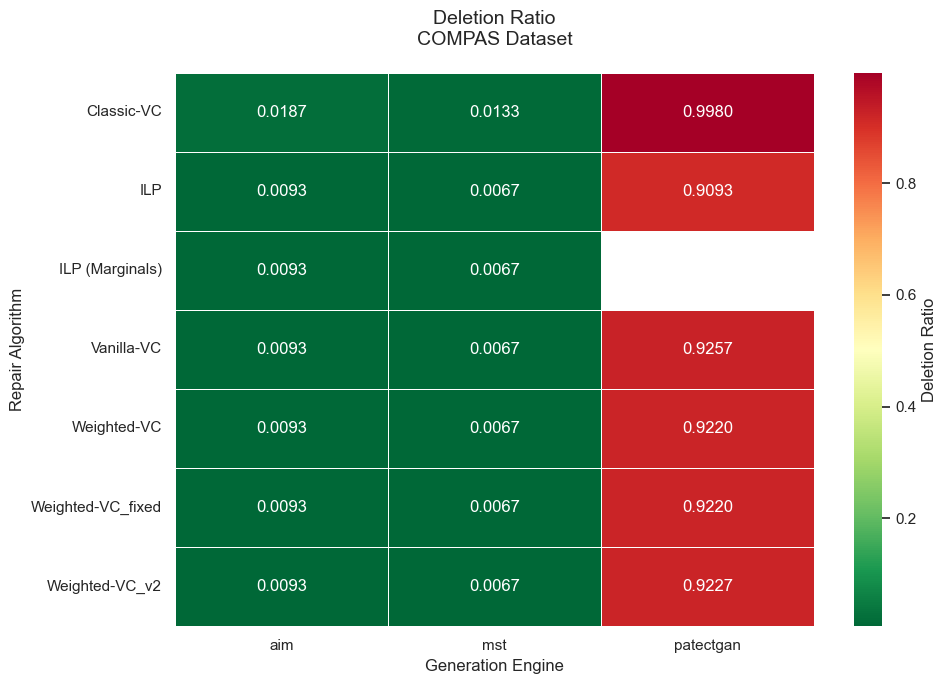


### Total Variation Distance (TVD)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.019631,0.031573,0.845042
ILP,0.018844,0.031110,0.599915
ILP (Marginals),0.018970,0.031110,NaN
Vanilla-VC,0.019013,0.031078,0.609631
Weighted-VC,0.018970,0.031078,0.589583
Weighted-VC_fixed,0.018970,0.031078,0.589583
Weighted-VC_v2,0.018970,0.031078,0.601527


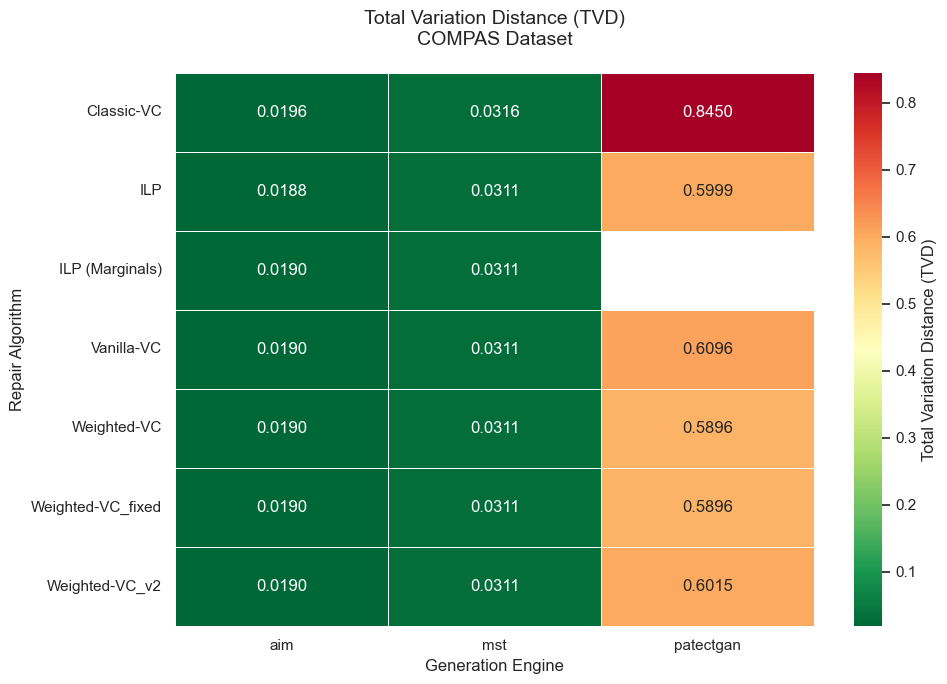


### Marginal Error


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.084388,0.398156,5.648096e+06
ILP,0.084094,0.399915,5.376475e+00
ILP (Marginals),0.083822,0.399915,NaN
Vanilla-VC,0.083877,0.399915,4.713117e+00
Weighted-VC,0.083822,0.399915,4.979911e+00
Weighted-VC_fixed,0.083822,0.399915,4.979911e+00
Weighted-VC_v2,0.083822,0.399915,4.529023e+00


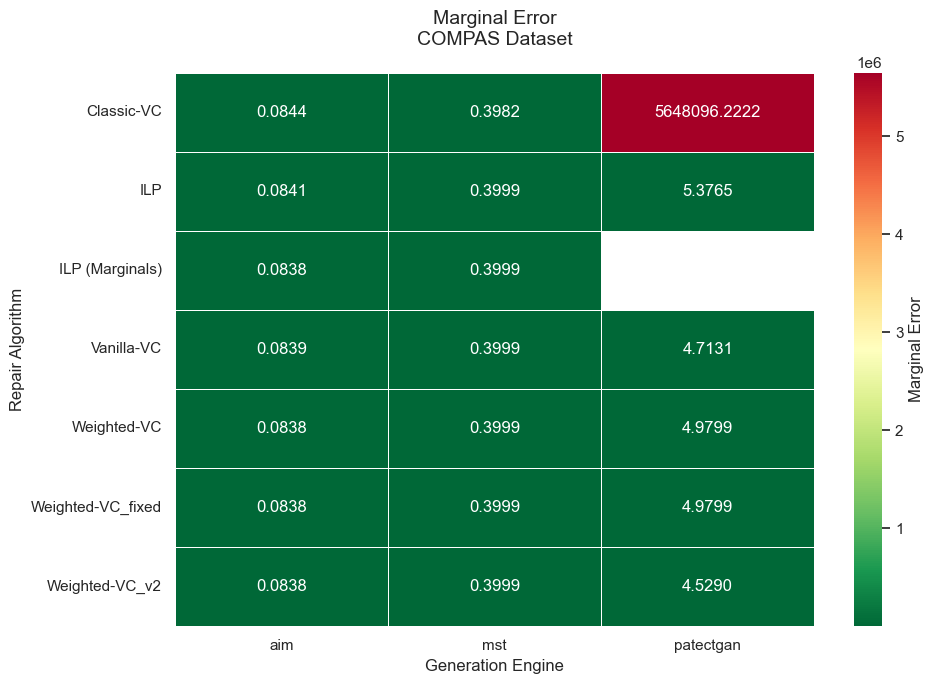


### Repair Runtime (seconds)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.041010,0.035154,3.742794
ILP,0.488861,0.183639,105.477168
ILP (Marginals),8.499270,4.795628,NaN
Vanilla-VC,0.040349,0.033022,4.211775
Weighted-VC,0.059025,0.046740,4.777704
Weighted-VC_fixed,0.063444,0.059913,5.321621
Weighted-VC_v2,0.061698,0.057511,5.521155


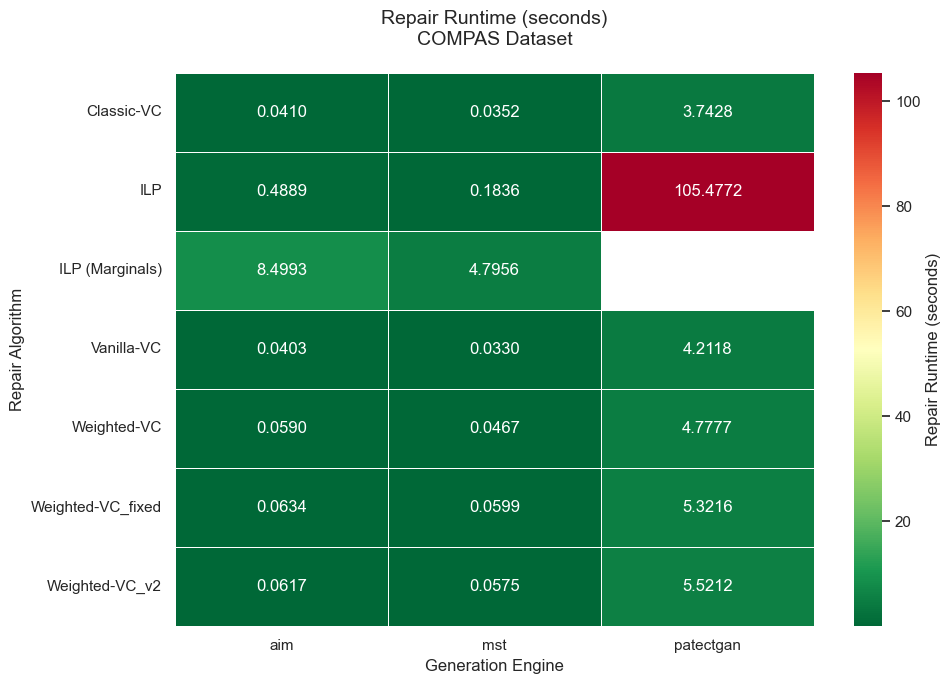


### Synthetic Marginals Distance


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.013318,0.042096,0.588112
ILP,0.013318,0.042096,0.588112
ILP (Marginals),0.013318,0.042096,NaN
Vanilla-VC,0.013318,0.042096,0.588112
Weighted-VC,0.013318,0.042096,0.588112
Weighted-VC_fixed,0.013318,0.042096,0.588112
Weighted-VC_v2,0.013318,0.042096,0.588112


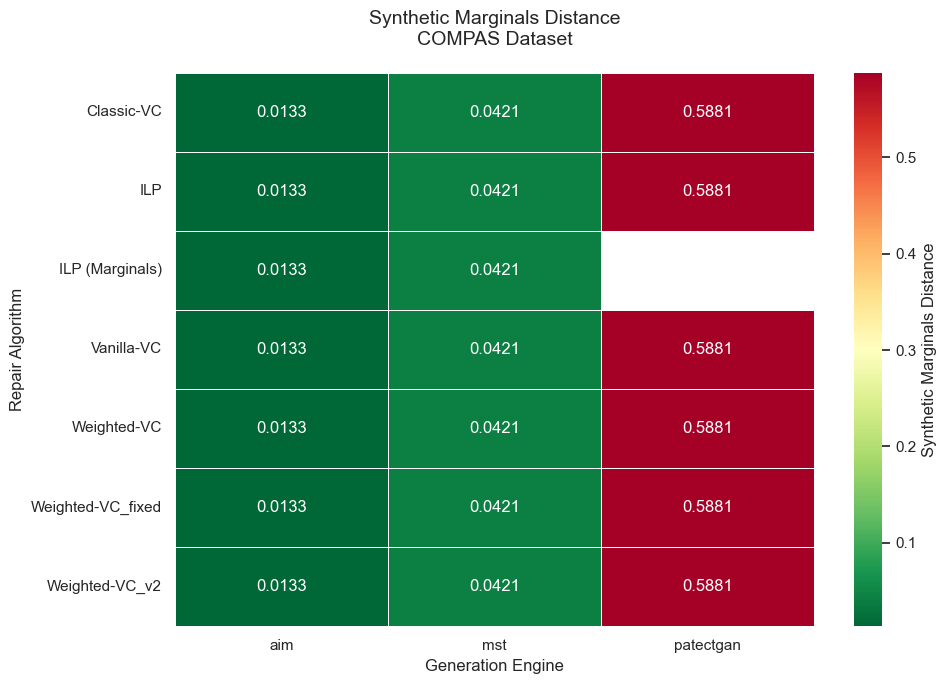


### TVD to Synthetic Data


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.018981,0.030841,0.57677
ILP,0.018981,0.030841,0.57677
ILP (Marginals),0.018981,0.030841,NaN
Vanilla-VC,0.018981,0.030841,0.57677
Weighted-VC,0.018981,0.030841,0.57677
Weighted-VC_fixed,0.018981,0.030841,0.57677
Weighted-VC_v2,0.018981,0.030841,0.57677


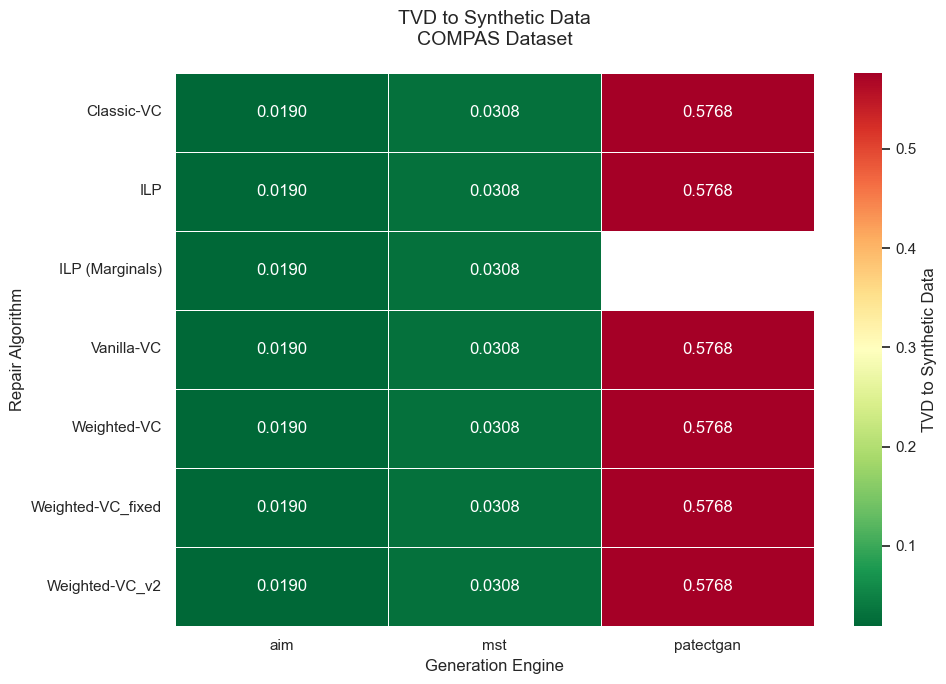


### Total Loss Function Value


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.016038,0.028094,0.810853
ILP,0.011277,0.024569,0.746419
ILP (Marginals),0.011252,0.024569,NaN
Vanilla-VC,0.011260,0.024569,0.747661
Weighted-VC,0.011252,0.024569,0.743786
Weighted-VC_fixed,0.011252,0.024569,0.743786
Weighted-VC_v2,0.011252,0.024569,0.744423


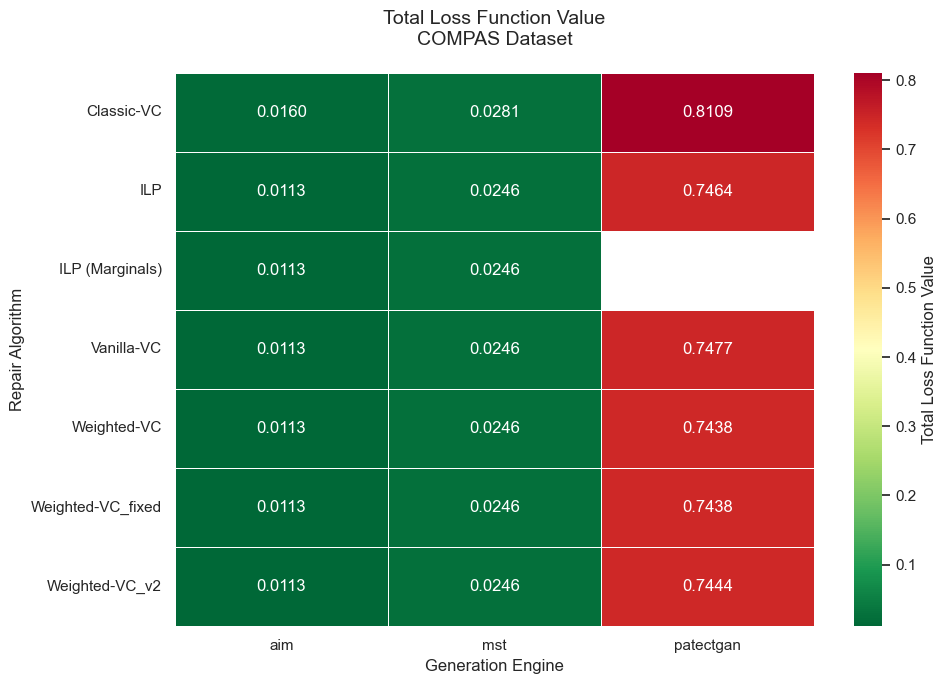


### Marginals Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.013409,0.042854,0.623707
ILP,0.013221,0.042472,0.583505
ILP (Marginals),0.013170,0.042472,NaN
Vanilla-VC,0.013187,0.042472,0.569655
Weighted-VC,0.013170,0.042472,0.565572
Weighted-VC_fixed,0.013170,0.042472,0.565572
Weighted-VC_v2,0.013170,0.042472,0.566179


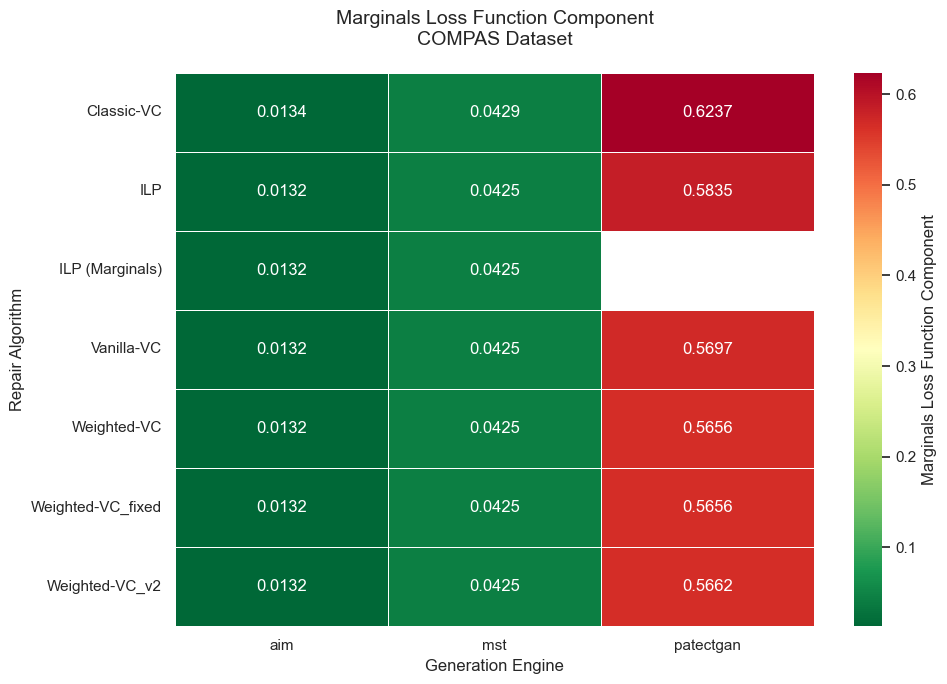


### Size Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.018667,0.013333,0.998000
ILP,0.009333,0.006667,0.909333
ILP (Marginals),0.009333,0.006667,NaN
Vanilla-VC,0.009333,0.006667,0.925667
Weighted-VC,0.009333,0.006667,0.922000
Weighted-VC_fixed,0.009333,0.006667,0.922000
Weighted-VC_v2,0.009333,0.006667,0.922667


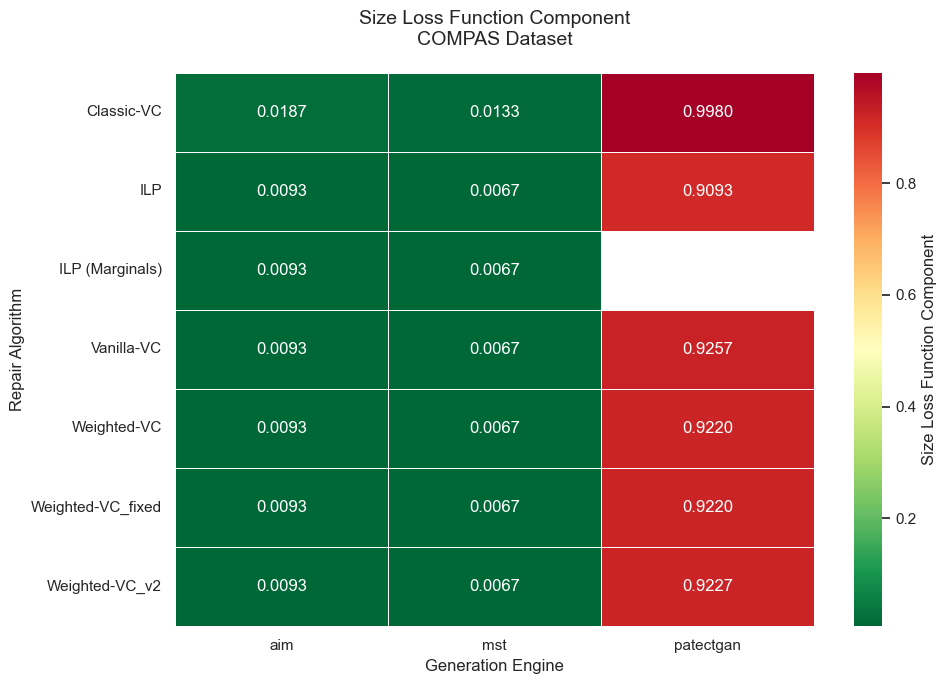


### ML Accuracy Repaired Logistic Regression


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.674808,0.584970,0.005219
ILP,0.674282,0.584822,0.013734
ILP (Marginals),0.674978,0.584822,NaN
Vanilla-VC,0.674699,0.587459,0.038280
Weighted-VC,0.674978,0.587459,0.039787
Weighted-VC_fixed,0.674978,0.587459,0.039787
Weighted-VC_v2,0.674978,0.587459,0.034552


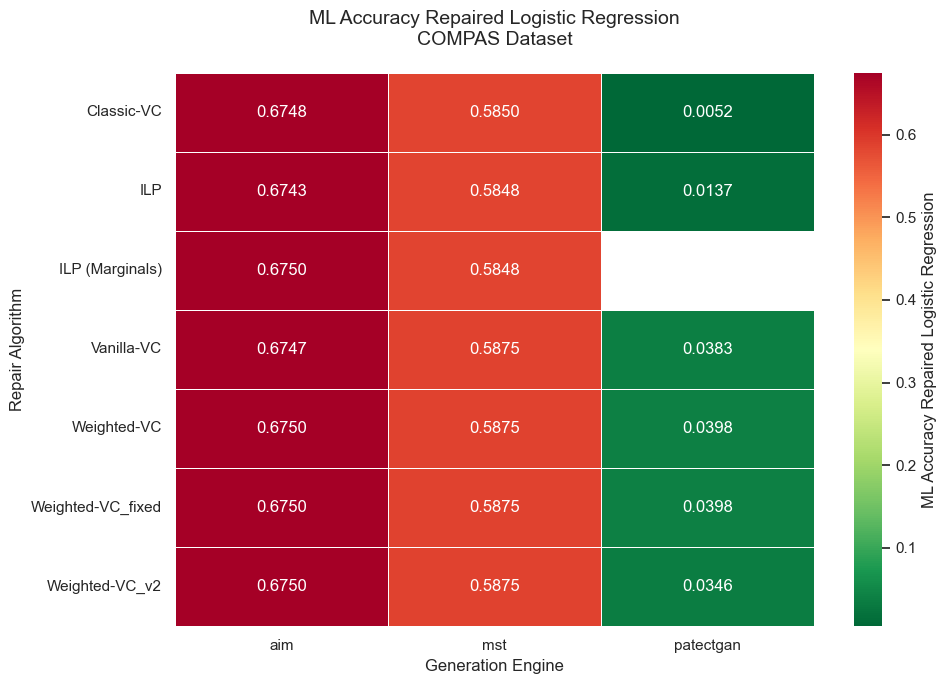


### ML Accuracy Repaired Random Forest


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.705610,0.619001,0.005159
ILP,0.708406,0.615656,0.016009
ILP (Marginals),0.707118,0.615656,NaN
Vanilla-VC,0.706087,0.616056,0.016179
Weighted-VC,0.707118,0.616056,0.033883
Weighted-VC_fixed,0.707118,0.616056,0.033883
Weighted-VC_v2,0.707118,0.616056,0.015697


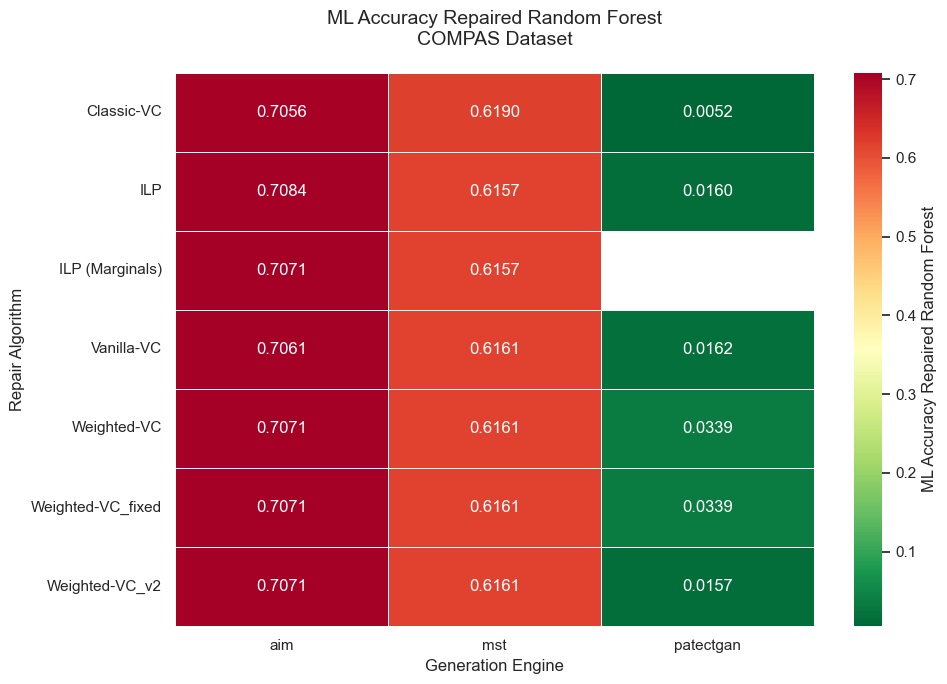


### ML Accuracy Repaired MLP


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.669134,0.539650,0.005132
ILP,0.667582,0.540319,0.011574
ILP (Marginals),0.668679,0.540319,NaN
Vanilla-VC,0.669934,0.540259,0.042737
Weighted-VC,0.668679,0.540259,0.027068
Weighted-VC_fixed,0.668679,0.540259,0.027068
Weighted-VC_v2,0.668679,0.540259,0.039925


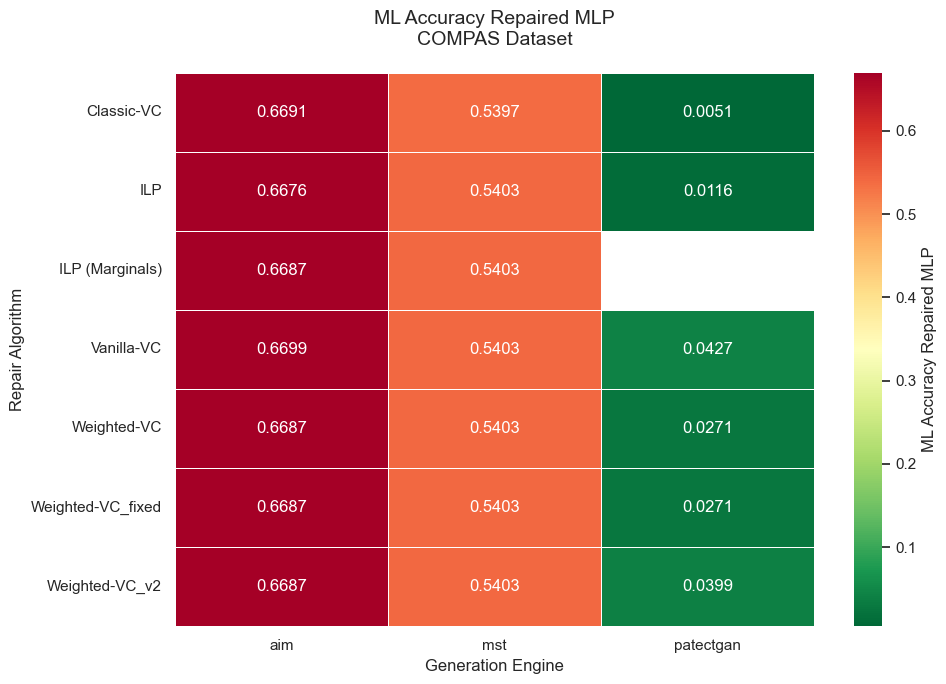

In [68]:
analyze_dataset('compas')

## Dataset: TAX


# Analysis for Dataset: TAX

### Deletion Ratio


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.178000,0.476667,0.962000
ILP,0.107000,0.295333,0.890333
ILP (Marginals),0.107000,0.295333,1.000000
Vanilla-VC,0.107333,0.296000,0.895000
Weighted-VC,0.107333,0.297000,0.895000
Weighted-VC_fixed,0.107333,0.297000,0.895000
Weighted-VC_v2,0.107333,0.296333,0.895000


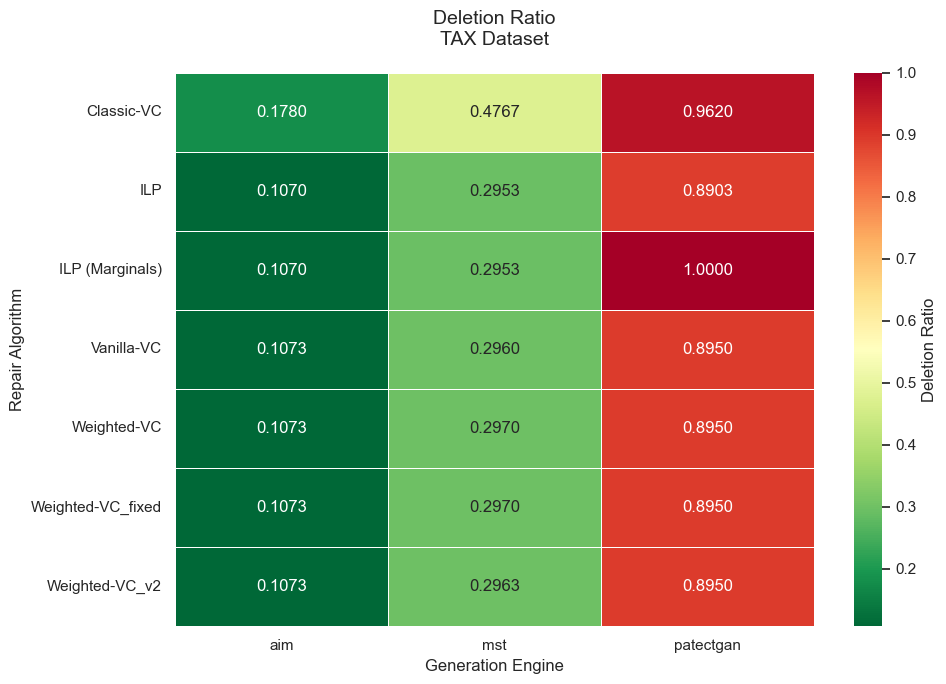


### Total Variation Distance (TVD)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.140599,0.269737,0.784452
ILP,0.124045,0.194933,0.666336
ILP (Marginals),0.122953,0.193968,0.500000
Vanilla-VC,0.124425,0.195562,0.651296
Weighted-VC,0.123164,0.194966,0.610912
Weighted-VC_fixed,0.123164,0.194966,0.610912
Weighted-VC_v2,0.123175,0.194555,0.617400


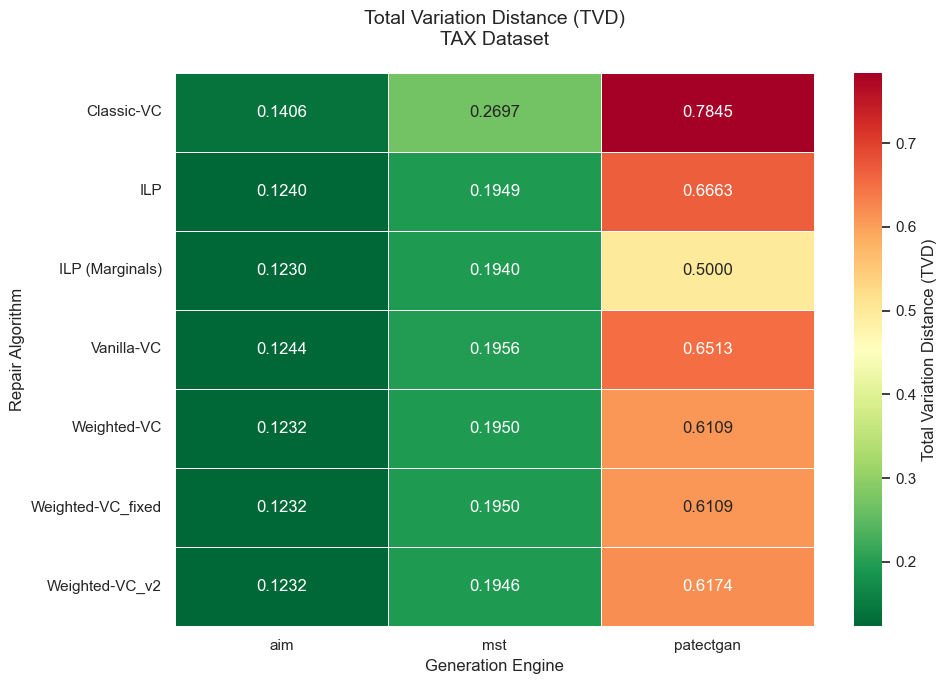


### Marginal Error


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.214739,0.869499,1.889726e+06
ILP,0.224561,0.682704,1.232328e+06
ILP (Marginals),0.218619,0.669996,3.447028e+06
Vanilla-VC,0.227588,0.671589,1.136274e+06
Weighted-VC,0.218353,0.683345,3.702137e+05
Weighted-VC_fixed,0.218353,0.683345,3.702137e+05
Weighted-VC_v2,0.218891,0.684264,5.191689e+05


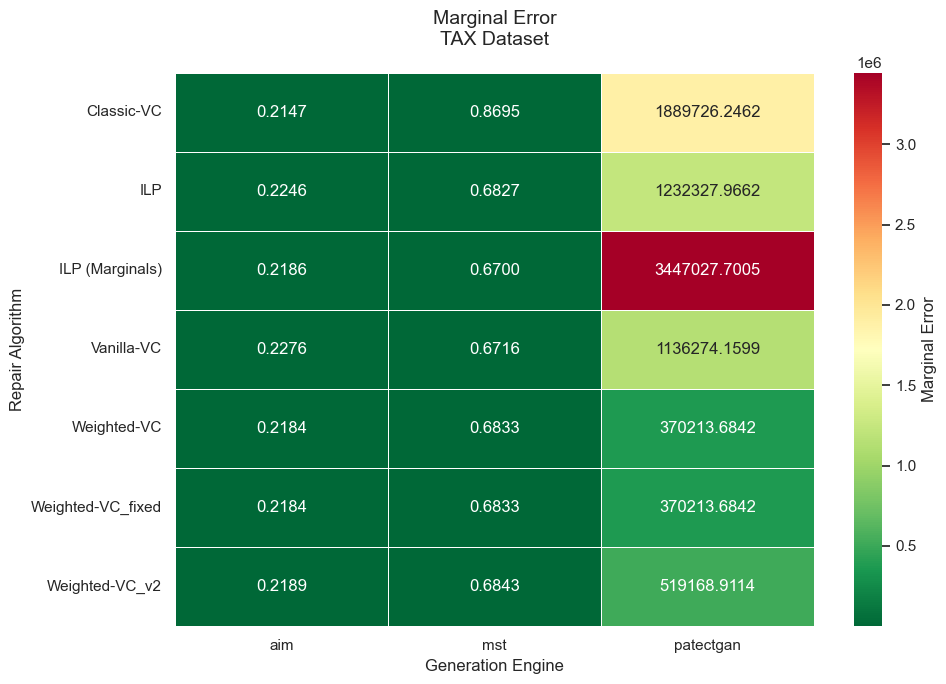


### Repair Runtime (seconds)


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.149350,0.272626,6.855024
ILP,0.445624,0.495977,6.792631
ILP (Marginals),47.762350,547.996663,445.784400
Vanilla-VC,0.152401,0.298609,7.034050
Weighted-VC,0.210436,0.698022,8.364808
Weighted-VC_fixed,0.241201,0.744680,8.046343
Weighted-VC_v2,0.226810,0.718466,8.023371


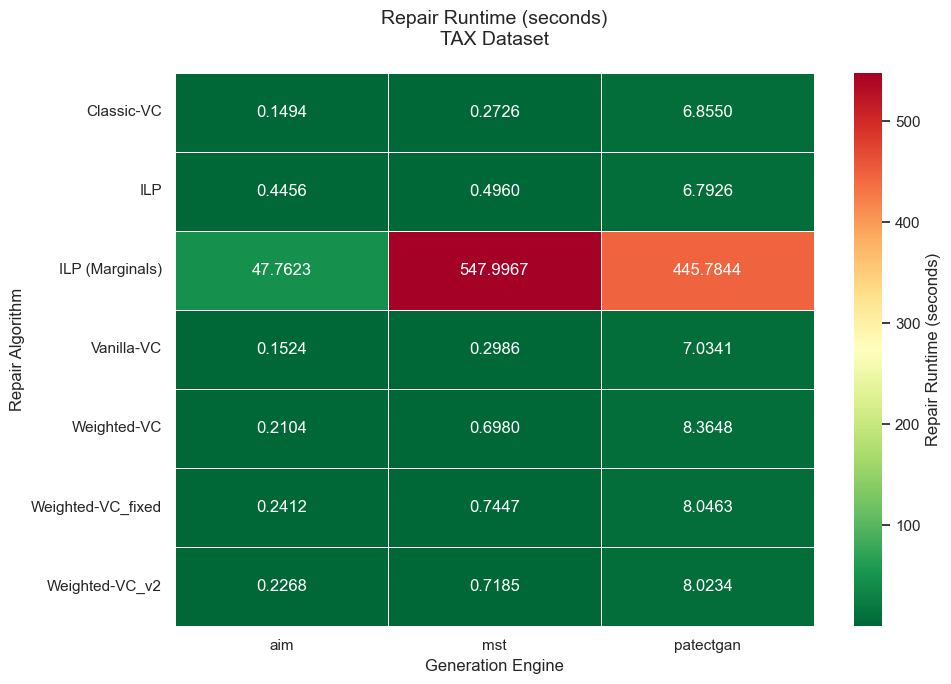


### Synthetic Marginals Distance


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.0116,0.067576,0.329953
ILP,0.0116,0.067576,0.329953
ILP (Marginals),0.0116,0.067576,0.329953
Vanilla-VC,0.0116,0.067576,0.329953
Weighted-VC,0.0116,0.067576,0.329953
Weighted-VC_fixed,0.0116,0.067576,0.329953
Weighted-VC_v2,0.0116,0.067576,0.329953


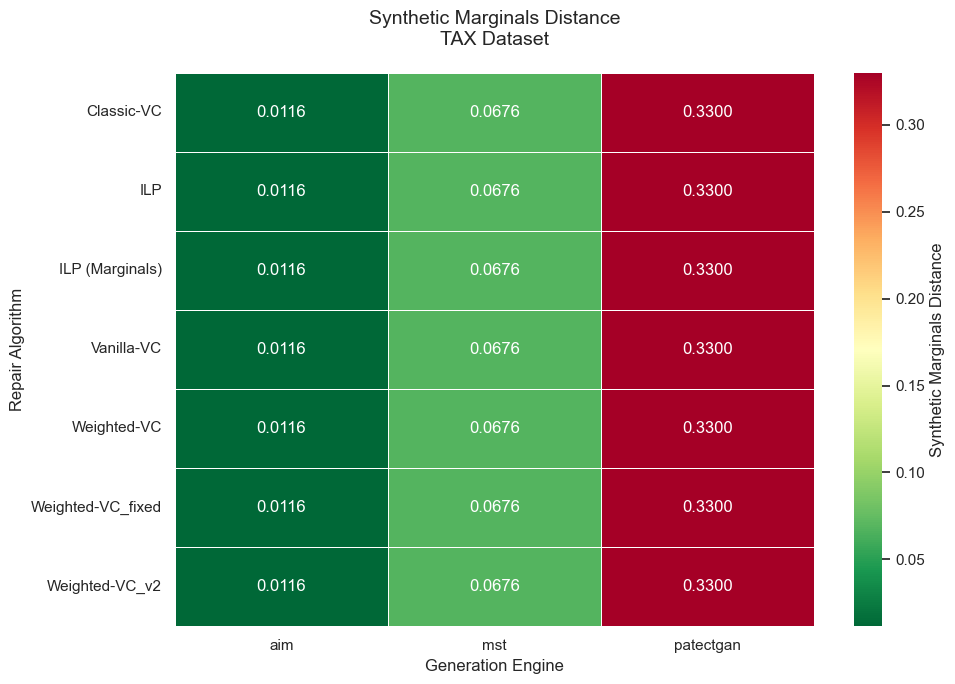


### TVD to Synthetic Data


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.110474,0.133764,0.581929
ILP,0.110474,0.133764,0.581929
ILP (Marginals),0.110474,0.133764,0.581929
Vanilla-VC,0.110474,0.133764,0.581929
Weighted-VC,0.110474,0.133764,0.581929
Weighted-VC_fixed,0.110474,0.133764,0.581929
Weighted-VC_v2,0.110474,0.133764,0.581929


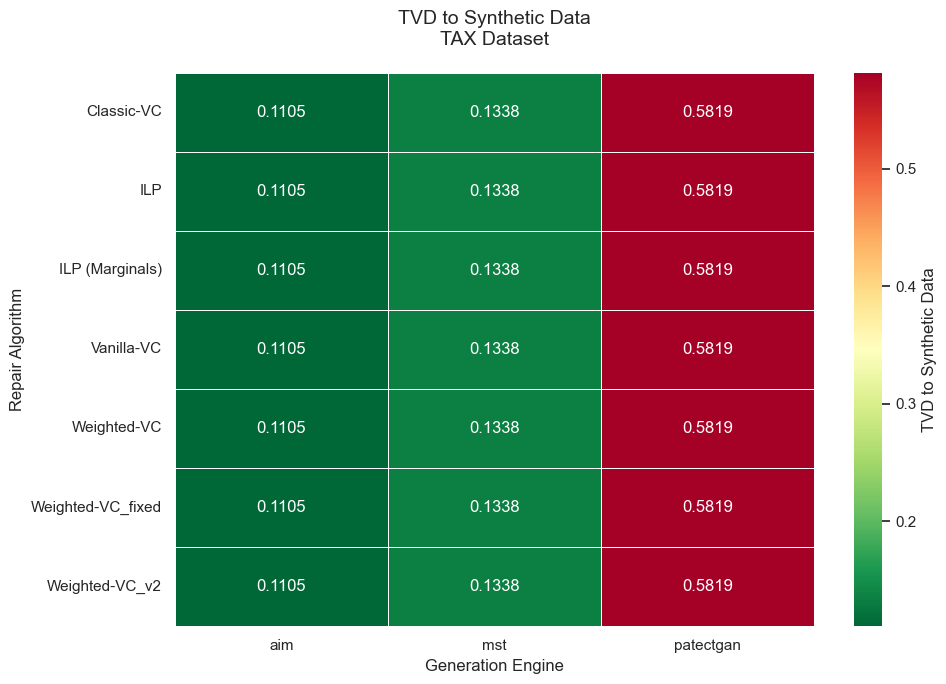


### Total Loss Function Value


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.095414,0.306010,0.644886
ILP,0.059612,0.196774,0.610673
ILP (Marginals),0.058907,0.195533,0.672351
Vanilla-VC,0.059944,0.196850,0.612864
Weighted-VC,0.059042,0.196697,0.593900
Weighted-VC_fixed,0.059042,0.196697,0.593900
Weighted-VC_v2,0.059042,0.196353,0.596940


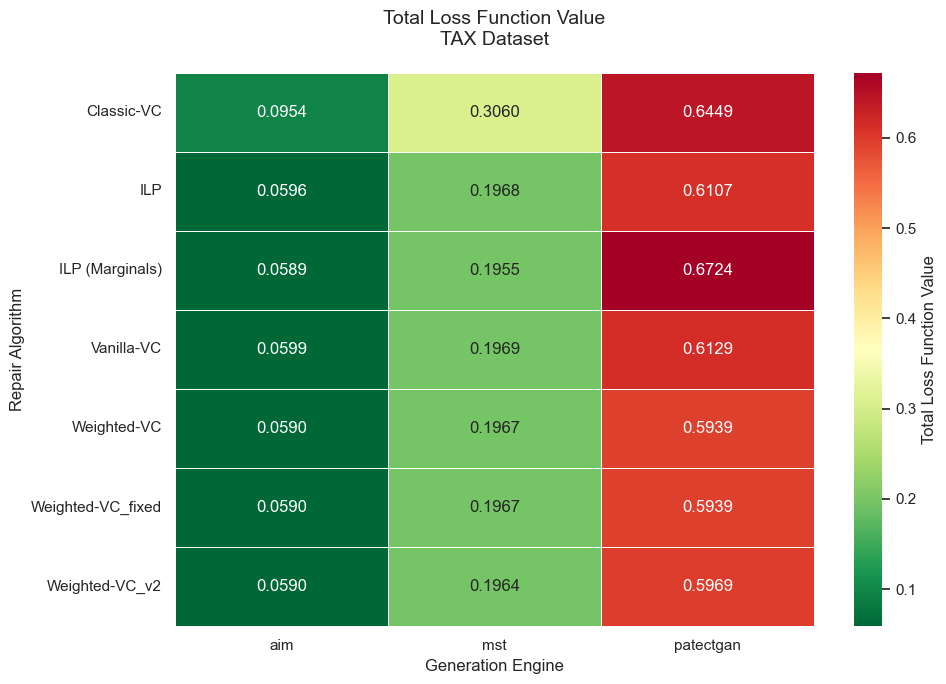


### Marginals Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.012828,0.135352,0.327772
ILP,0.012224,0.098214,0.331012
ILP (Marginals),0.010814,0.095732,0.344703
Vanilla-VC,0.012554,0.097701,0.330729
Weighted-VC,0.010751,0.096394,0.292799
Weighted-VC_fixed,0.010751,0.096394,0.292799
Weighted-VC_v2,0.010751,0.096373,0.298879


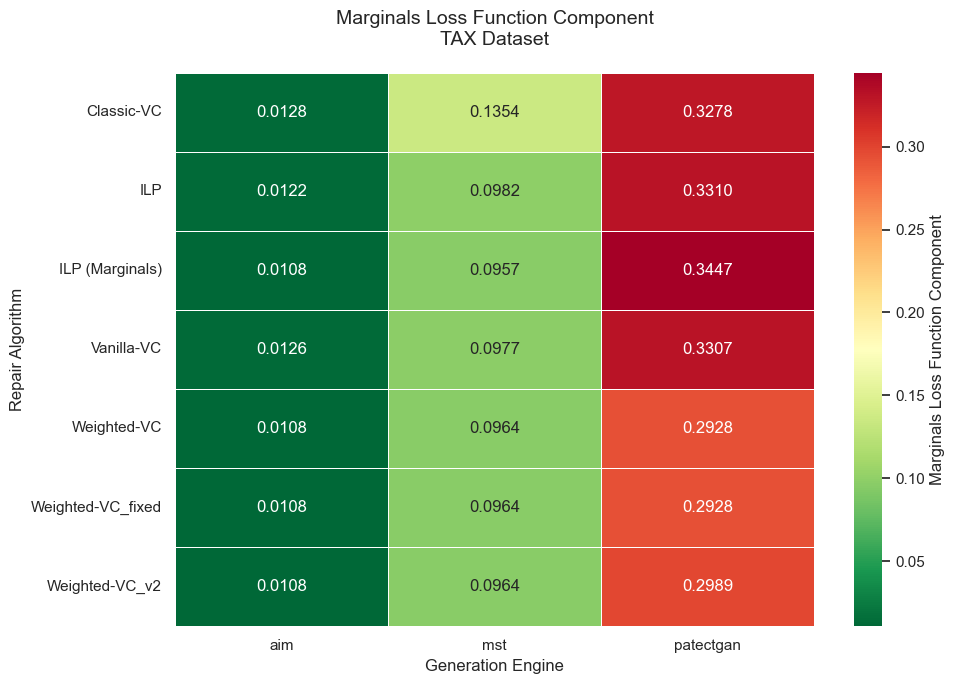


### Size Loss Function Component


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.178000,0.476667,0.962000
ILP,0.107000,0.295333,0.890333
ILP (Marginals),0.107000,0.295333,1.000000
Vanilla-VC,0.107333,0.296000,0.895000
Weighted-VC,0.107333,0.297000,0.895000
Weighted-VC_fixed,0.107333,0.297000,0.895000
Weighted-VC_v2,0.107333,0.296333,0.895000


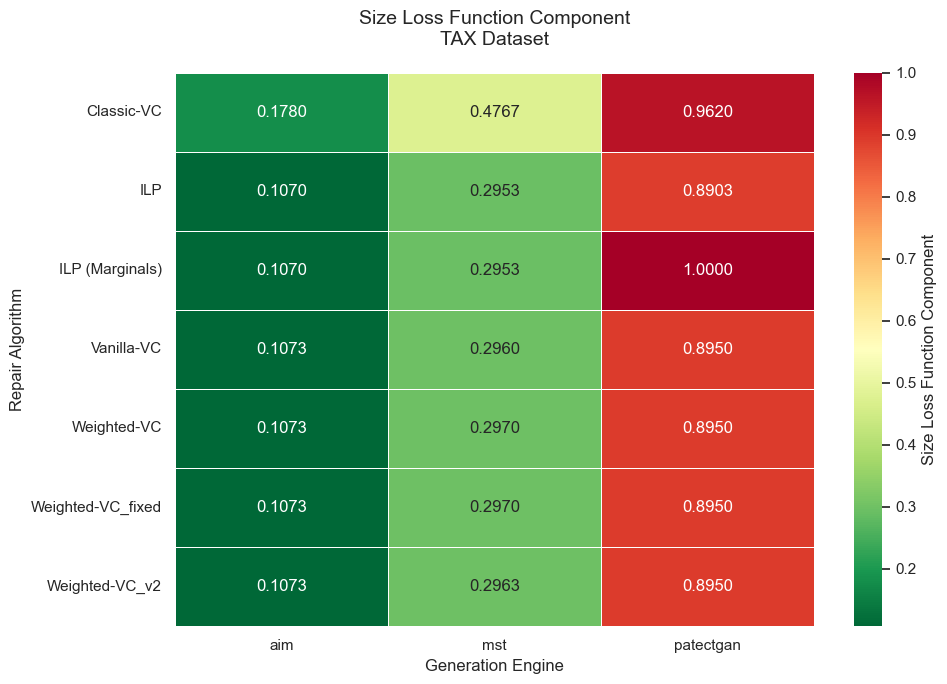


### ML Accuracy Repaired Logistic Regression


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.332416,0.313550,0.014744
ILP,0.331986,0.318697,0.017249
ILP (Marginals),0.331971,0.317926,0.000000
Vanilla-VC,0.332248,0.317971,0.039628
Weighted-VC,0.333196,0.317918,0.028550
Weighted-VC_fixed,0.333196,0.317918,0.028550
Weighted-VC_v2,0.332960,0.317383,0.030188


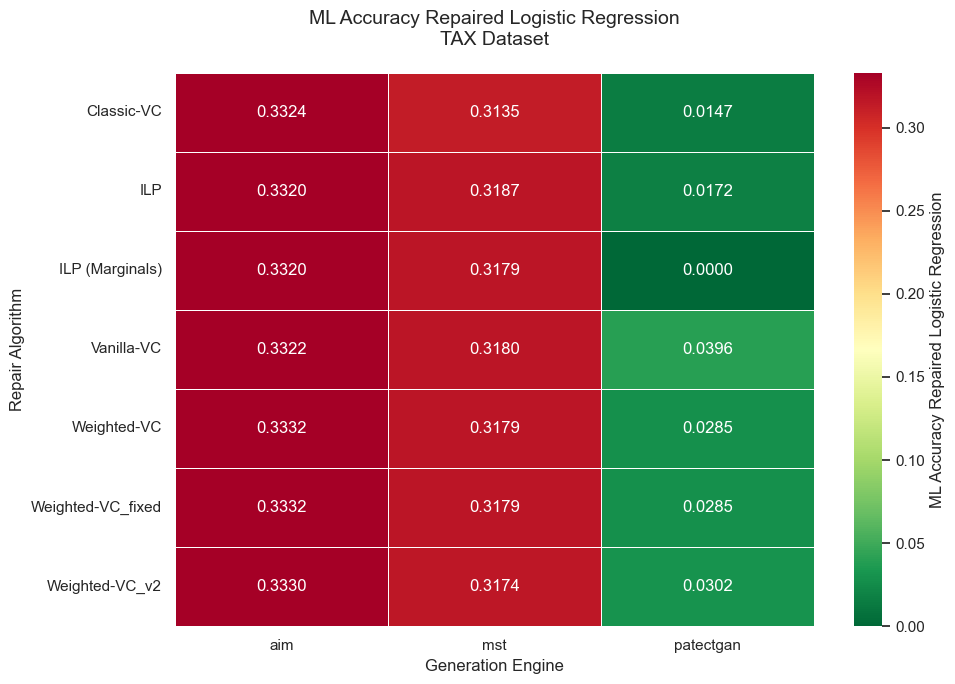


### ML Accuracy Repaired Random Forest


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.686650,0.557829,0.010814
ILP,0.692683,0.621513,0.016170
ILP (Marginals),0.693906,0.621191,0.000000
Vanilla-VC,0.693023,0.618685,0.033449
Weighted-VC,0.696480,0.619156,0.022919
Weighted-VC_fixed,0.696480,0.619156,0.022919
Weighted-VC_v2,0.696129,0.621918,0.025574


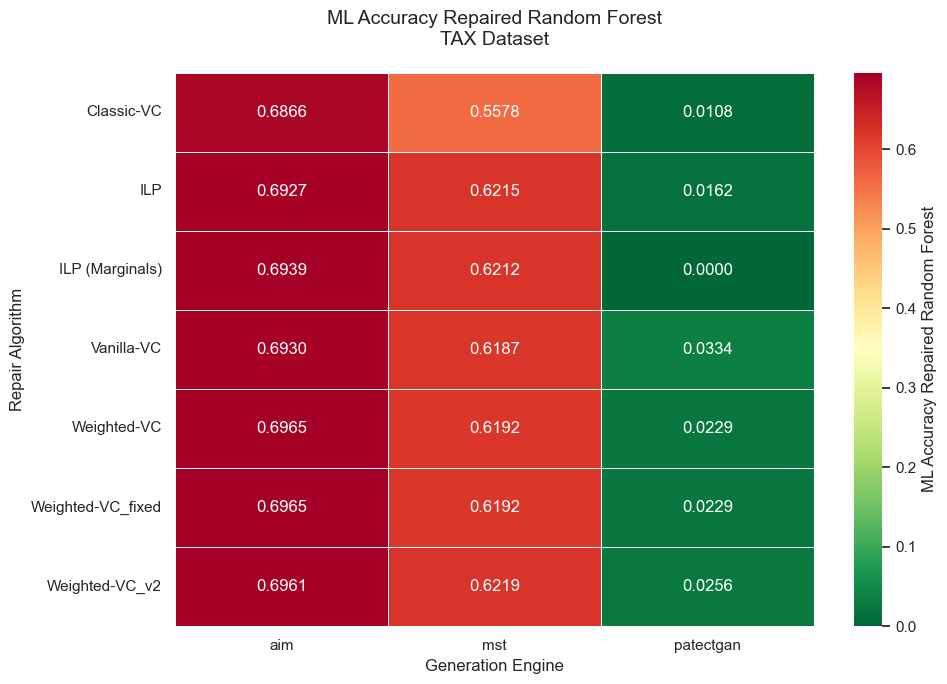


### ML Accuracy Repaired MLP


engine,aim,mst,patectgan
repairer,,,
Classic-VC,0.528260,0.379445,0.015877
ILP,0.530181,0.407170,0.015812
ILP (Marginals),0.521182,0.398729,0.000000
Vanilla-VC,0.524951,0.403851,0.036925
Weighted-VC,0.531419,0.407282,0.037191
Weighted-VC_fixed,0.531419,0.407282,0.037191
Weighted-VC_v2,0.525653,0.409319,0.038641


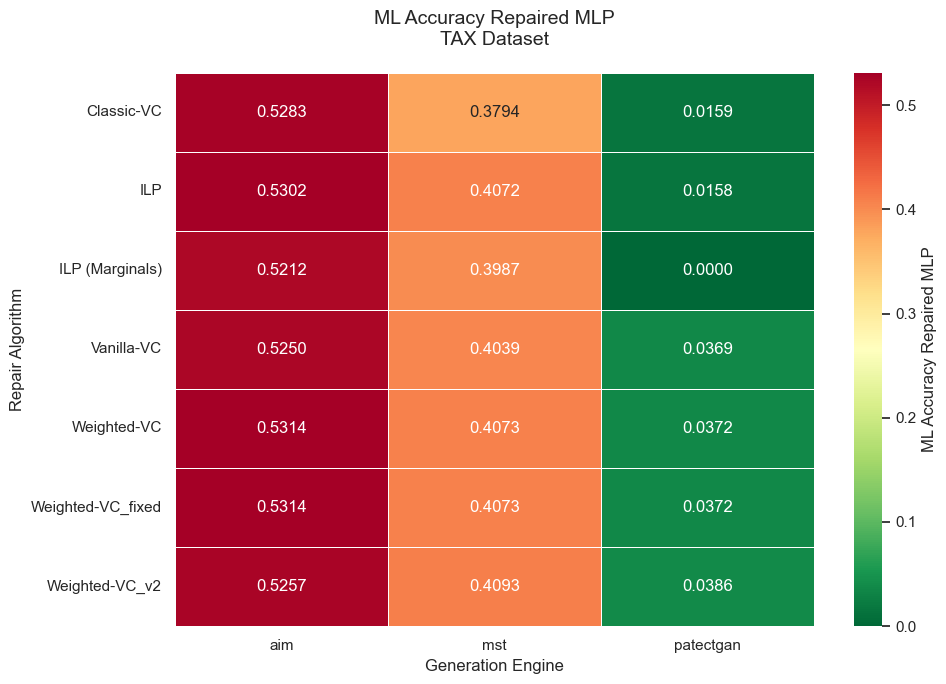

In [69]:
analyze_dataset('tax')